## Gold Comparison & Evaluation (Deliverable 1.3.4)

This notebook performs the final comparison between the baseline model and the three-stage cascade. It evaluates whether the cascade meaningfully improves alert quality by reducing false positives and noisy alerts while preserving useful anomaly sensitivity.

**Purpose:**  
To combine the alert outputs from the Baseline Modeling and Cascade Modeling notebooks, compute evaluation metrics, perform paired statistical testing, and generate the comparative visualizations required for Section C.

**Key Goals:**

- Load baseline and cascade alert outputs.
- Align alerts into comparable time windows for paired evaluation.
- Compute alert-volume metrics, false-positive rates, normal-period alerts, and anomaly responsiveness.
- Perform the planned statistical significance test (paired/Wilcoxon) to quantify model differences.
- Produce comparison tables, charts, and anomaly overlays for Section C.6.
- Summarize both practical and statistical significance findings based on the project’s research question.

**Relevance to Section C:**  
This notebook fulfills the analytical requirements of C.2, C.4, C.5, and C.6 by generating:  
- The model comparison metrics,  
- The statistical significance results,  
- The practical significance interpretation, and  
- All visual communication elements needed for the final report.

This completes the Gold layer and provides the definitive evidence used to answer the project’s research question.

## Gold Comparison Setup and Imports

In this section I am loading the libraries and project utilities needed for the Gold comparison stage.

The purpose here is to get the notebook ready before I start comparing the baseline and cascade outputs. That includes:
- standard Python libraries
- plotting utilities
- path and config loading
- logging
- truth-record helpers
- artifact saving utilities
- experiment tracking support

At this point I am not comparing model performance yet. I am just preparing the notebook so the comparison workflow can run in a structured and repeatable way.

In [4]:
from __future__ import annotations


from dataclasses import dataclass, field
from datetime import datetime, timezone
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union, cast

from pathlib import Path
import yaml
import re

import os
import logging
import wandb

import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import seaborn as sns 

import joblib 

from math import sqrt


from scipy.stats import norm

try:
    from statsmodels.stats.contingency_tables import mcnemar
    HAS_STATSMODELS_MCNEMAR = True
except Exception:
    HAS_STATSMODELS_MCNEMAR = False

from sklearn.model_selection import train_test_split, KFold

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, RobustScaler

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, roc_auc_score, average_precision_score

from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

import pyarrow.parquet as pq
import pyarrow as pa

from IPython.display import HTML


import hashlib


# Custom Utilities Module
from utils.core.paths import get_paths

from utils.core.file_io import (
    load_data, 
    save_data, 
    save_json, 
    load_json,
)

from utils.core.logging_profiler import profile_dataframe

from utils.core.logging_setup import (
    configure_logging, 
    log_layer_paths, 
)

from utils.core.wandb_utils import finalize_wandb_stage

from utils.core.truths import (
    make_process_run_id,
    build_file_fingerprint,
    extract_truth_hash,
    identify_meta_columns,
    identify_feature_columns,
    initialize_layer_truth,
    update_truth_section,
    build_truth_record,
    save_truth_record,
    append_truth_index,
    stamp_truth_columns,
    load_truth_record,
    find_truth_record_by_hash,
    load_truth_record_by_hash,
    load_parent_truth_record_from_dataframe,
    get_truth_value,
    get_dataset_name_from_truth,
    get_truth_hash,
    get_parent_truth_hash,
    get_pipeline_mode_from_truth,
    get_artifact_path_from_truth,
)

from utils.core.config_loader import (
    load_pipeline_config,
    build_truth_config_block,
    set_wandb_dir_from_config,
    export_config_snapshot,
)

from utils.database.postgres import (
    get_engine_from_env, 
    read_sql_dataframe,
)
from utils.database.layer_postgres import (
    read_layer_dataframe, 
    write_layer_dataframe, 
    prepare_layer_dataframe,
)

from utils.database.sql_notebook_helpers import (
    delete_dataset_run_rows,
    execute_many,
    get_existing_dataframe,
    get_row_value,
    log_data_quality_event,
    log_pipeline_artifact,
    preview_sql_table,
    row_to_payload,
    sql_table_ref,
    to_builtin,
    to_json_string,
    to_scalar,
    upsert_pipeline_run,
)


from utils.database.medallion_sql_writers import (
    log_gold_05_anomaly_detection_summary_sql,
    log_silver_eda_sql,
    write_bronze_sensor_observations_sql,
    write_gold_baseline_scores_sql,
    write_gold_cascade_scores_sql,
    write_gold_model_comparison_results_sql,
    write_gold_preprocessed_features_sql,
    write_silver_sensor_observation_features_sql,
)

# Ledger 
from utils.core.ledger import Ledger


from utils.core.artifacts import (
    build_artifact_dirs_from_config,
    build_artifact_dirs,
    artifact_file_path,
)

# Show more columns
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)


----

In [5]:
# --------------------------------------------------------------------------------
#
# --------------------------------------------------------------------------------

def require_truth_record(value: Any, name: str) -> dict[str, Any]:
    """
    Validate a loaded truth record.
    """
    if not isinstance(value, dict):
        raise TypeError(
            f"{name} must be a dictionary. "
            f"Got {type(value).__name__}: {value!r}"
        )

    return value

# --------------------------------------------------------------------------------
#
# --------------------------------------------------------------------------------

def get_nested_mapping(
    value: dict[str, Any],
    key: str,
    name: str,
) -> dict[str, Any]:
    """
    Safely extract a nested dictionary from a truth/config record.
    """
    raw_value = value.get(key, {})

    if raw_value is None:
        return {}

    if not isinstance(raw_value, dict):
        raise TypeError(
            f"{name}.{key} must be a dictionary. "
            f"Got {type(raw_value).__name__}: {raw_value!r}"
        )

    return raw_value

# --------------------------------------------------------------------------------
#
# --------------------------------------------------------------------------------

def require_mapping(value: Any, name: str) -> dict[str, Any]:
    """
    Validate that a loaded JSON/config object is a dictionary.
    """
    if not isinstance(value, dict):
        raise TypeError(
            f"{name} must be a dictionary. "
            f"Got {type(value).__name__}: {value!r}"
        )

    return value

# --------------------------------------------------------------------------------
#
# --------------------------------------------------------------------------------

def normalize_text_value(value: Any) -> str:
    """
    Convert any scalar value into lowercase stripped text.
    """
    if value is None:
        return ""

    return str(value).strip().lower()

----

## Load Configuration, Paths, and Comparison Runtime Settings

Here I load the resolved configuration values that control how the Gold comparison notebook runs.

This step defines the key runtime pieces for the comparison stage, such as:
- dataset identity
- Gold version and recipe information
- comparison artifact file names
- truth-store locations
- baseline and cascade artifact paths
- experiment tracking settings

I like doing this early because it keeps the rest of the notebook cleaner. Instead of scattering file paths and settings throughout the notebook, I define them once here and reuse them later.

In [10]:
paths = get_paths()

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### #### 

CONFIG_ROOT = paths.configs
CONFIG_RUN_MODE = "train"
CONFIG_PROFILE = "default"

CONFIG = load_pipeline_config(
    config_root=CONFIG_ROOT,
    stage="gold_comparison",
    dataset="pump",
    mode=CONFIG_RUN_MODE,
    profile=CONFIG_PROFILE,
    project_root=paths.root,
).data


COMPARISON_CFG = cast(Dict[str, Any], CONFIG["gold_comparison"])
PATHS = cast(Dict[str, Any], CONFIG["resolved_paths"])
FILENAMES = cast(Dict[str, Any], CONFIG["filenames"])
VERSIONS_CFG = cast(Dict[str, Any], CONFIG["versions"])

PIPELINE = cast(
    Dict[str, Any],
    CONFIG.get(
        "pipeline",
        {
            "execution_mode": "batch",
            "orchestration_mode": "notebook",
        },
    ),
)


RUNTIME_CFG = cast(Dict[str, Any], CONFIG["runtime"])
DATASET_CFG = cast(Dict[str, Any], CONFIG["dataset"])
WANDB_CFG = cast(Dict[str, Any], CONFIG["wandb"])
EXECUTION_CFG = cast(Dict[str, Any], CONFIG.get("execution", {}))

TRUTH_CONFIG = cast(Dict[str, Any], build_truth_config_block(CONFIG))
TRUTH_CONFIG["pipeline"] = PIPELINE
TRUTH_CONFIG["stage_params"] = COMPARISON_CFG

# Stage Details
STAGE = "gold"
LAYER_NAME = COMPARISON_CFG["layer_name"]

GOLD_VERSION = str(VERSIONS_CFG["gold"])
TRUTH_VERSION = str(VERSIONS_CFG["truth"])
RECIPE_ID = str(COMPARISON_CFG["recipe_id"])

PIPELINE_MODE = str(PIPELINE["execution_mode"])
RUN_MODE = str(RUNTIME_CFG["mode"])

DATASET_NAME_CONFIG = str(DATASET_CFG["name"])
DATASET_NAME = str(DATASET_NAME_CONFIG).strip().lower()

GOLD_PROCESS_RUN_ID = make_process_run_id(
    str(COMPARISON_CFG["process_run_id_prefix"])
)

PROCESS_RUN_ID = GOLD_PROCESS_RUN_ID


#### #### #### ####
# Weights and Biases

WANDB_PROJECT = str(WANDB_CFG["project"])
WANDB_ENTITY = str(WANDB_CFG["entity"])
WANDB_RUN_NAME = f"{GOLD_VERSION}"

#### #### #### ####

# File names
BASELINE_RESULTS_FILE_NAME_CSV = FILENAMES["baseline_results_file_name_csv"]
BASELINE_RESULTS_FILE_NAME_PICKLE = FILENAMES["baseline_results_file_name_pickle"]
BASELINE_SUMMARY_FILE_NAME = FILENAMES["baseline_summary_file_name"]
BASELINE_THRESHOLDS_FILE_NAME = FILENAMES["baseline_thresholds_file_name"]
BASELINE_METADATA_FILE_NAME = FILENAMES["baseline_metadata_file_name"]

CASCADE_DEFAULTS_RESULTS_FILE_NAME_CSV = FILENAMES["cascade_defaults_results_file_name_csv"]
CASCADE_DEFAULTS_FILE_NAME_PICKLE = FILENAMES["cascade_defaults_results_file_name_pickle"]
CASCADE_DEFAULTS_SUMMARY_FILE_NAME = FILENAMES["cascade_defaults_summary_file_name"]
CASCADE_DEFAULTS_THRESHOLDS_FILE_NAME = FILENAMES["cascade_defaults_thresholds_file_name"]
CASCADE_DEFAULTS_METADATA_FILE_NAME = FILENAMES["cascade_defaults_metadata_file_name"]

CASCADE_TUNED_RESULTS_FILE_NAME_CSV = FILENAMES["cascade_tuned_results_file_name_csv"]
CASCADE_TUNED_RESULTS_FILE_NAME_PICKLE = FILENAMES["cascade_tuned_results_file_name_pickle"]
CASCADE_TUNED_SUMMARY_FILE_NAME = FILENAMES["cascade_tuned_summary_file_name"]
CASCADE_TUNED_THRESHOLDS_FILE_NAME = FILENAMES["cascade_tuned_thresholds_file_name"]
CASCADE_TUNED_METADATA_FILE_NAME = FILENAMES["cascade_tuned_metadata_file_name"]

CASCADE_STAGE3_IMPROVED_RESULTS_FILE_NAME_CSV = FILENAMES["cascade_stage3_improved_results_file_name_csv"]
CASCADE_STAGE3_IMPROVED_RESULTS_FILE_NAME_PICKLE = FILENAMES["cascade_stage3_improved_results_file_name_pickle"]
CASCADE_STAGE3_IMPROVED_SUMMARY_FILE_NAME = FILENAMES["cascade_stage3_improved_summary_file_name"]
CASCADE_STAGE3_IMPROVED_THRESHOLDS_FILE_NAME = FILENAMES["cascade_stage3_improved_thresholds_file_name"]
CASCADE_STAGE3_IMPROVED_METADATA_FILE_NAME = FILENAMES["cascade_stage3_improved_metadata_file_name"]

MODEL_COMPARISON_FILE_NAME = FILENAMES["model_comparison_file_name"]
MODEL_COMPARISON_SUMMARY_FILE_NAME = FILENAMES["model_comparison_summary_file_name"]

GOLD_COMPARISON_LEDGER_FILE_NAME = FILENAMES["gold_comparison_ledger_file_name"]
COMPARISON_PLOT_WITH_TEST_ALERTS_FILE_NAME = FILENAMES["comparison_plot_with_test_alerts_file_name"]

#### #### #### ####

# Paths

GOLD_ARTIFACTS_PATH = Path(PATHS["gold_artifacts_dir"])

BASELINE_RESULTS_PATH_CSV = Path(PATHS["baseline_results_path_csv"])
BASELINE_RESULTS_PATH_PICKLE = Path(PATHS["baseline_results_path_pickle"])
BASELINE_THRESHOLDS_PATH = Path(PATHS["baseline_thresholds_path"])
BASELINE_SUMMARY_PATH = Path(PATHS["baseline_summary_path"])
BASELINE_METADATA_PATH = Path(PATHS["baseline_metadata_path"])

CASCADE_DEFAULTS_RESULTS_PATH_CSV = Path(PATHS["cascade_defaults_results_path_csv"])
CASCADE_DEFAULTS_RESULTS_PATH_PICKLE = Path(PATHS["cascade_defaults_results_path_pickle"])
CASCADE_DEFAULTS_THRESHOLDS_PATH = Path(PATHS["cascade_defaults_thresholds_path"])
CASCADE_DEFAULTS_SUMMARY_PATH = Path(PATHS["cascade_defaults_summary_path"])
CASCADE_DEFAULTS_METADATA_PATH = Path(PATHS["cascade_defaults_metadata_path"])

CASCADE_TUNED_RESULTS_PATH_CSV = Path(PATHS["cascade_tuned_results_path_csv"])
CASCADE_TUNED_RESULTS_PATH_PICKLE = Path(PATHS["cascade_tuned_results_path_pickle"])
CASCADE_TUNED_THRESHOLDS_PATH = Path(PATHS["cascade_tuned_thresholds_path"])
CASCADE_TUNED_SUMMARY_PATH = Path(PATHS["cascade_tuned_summary_path"])
CASCADE_TUNED_METADATA_PATH = Path(PATHS["cascade_tuned_metadata_path"])

CASCADE_STAGE3_IMPROVED_RESULTS_PATH_CSV = Path(PATHS["cascade_stage3_improved_results_path_csv"])
CASCADE_STAGE3_IMPROVED_RESULTS_PATH_PICKLE = Path(PATHS["cascade_stage3_improved_results_path_pickle"])
CASCADE_STAGE3_IMPROVED_THRESHOLDS_PATH = Path(PATHS["cascade_stage3_improved_thresholds_path"])
CASCADE_STAGE3_IMPROVED_SUMMARY_PATH = Path(PATHS["cascade_stage3_improved_summary_path"])
CASCADE_STAGE3_IMPROVED_METADATA_PATH = Path(PATHS["cascade_stage3_improved_metadata_path"])

CASCADE_STAGE3_RESULTS_PATH_CSV = PATHS["cascade_tuned_results_path_csv"]
CASCADE_STAGE3_RESULTS_PATH_PICKLE = PATHS["cascade_tuned_results_path_pickle"]
CASCADE_STAGE3_SUMMARY_PATH = PATHS["cascade_tuned_summary_path"]
CASCADE_STAGE3_THRESHOLDS_PATH = PATHS["cascade_tuned_thresholds_path"]
CASCADE_STAGE3_METADATA_PATH = PATHS["cascade_tuned_metadata_path"]


#MODEL_COMPARISON_PATH = GOLD_ARTIFACTS_PATH / f"{DATASET_NAME}__gold__model_comparison.csv"
#MODEL_COMPARISON_SUMMARY_PATH = GOLD_ARTIFACTS_PATH / f"{DATASET_NAME}__gold__model_comparison_summary.json"

MODEL_COMPARISON_PATH = Path(PATHS["model_comparison_path"])
MODEL_COMPARISON_SUMMARY_PATH = Path(PATHS["model_comparison_summary_path"])

COMPARISON_PLOT_WITH_TEST_ALERTS_PATH = Path(PATHS["comparison_plot_with_test_alerts_path"]) 

# Logs
LOGS_PATH = Path(PATHS["logs_root"])

# Truths
TRUTHS_PATH = Path(PATHS["truths_dir"])
TRUTH_INDEX_PATH = Path(PATHS["truth_index_path"])


# Path Failsafes
GOLD_ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)
TRUTHS_PATH.mkdir(parents=True, exist_ok=True)
LOGS_PATH.mkdir(parents=True, exist_ok=True)

# Weights and Biases Directory
set_wandb_dir_from_config(CONFIG)


PosixPath('/workspace/wandb')

----

In [11]:
# =========================================================
# Gold comparison artifact directories
# =========================================================
# Gold 04 compares outputs from Gold 02 / 03A / 03B / 03C.
# Its CONFIG may not contain those notebooks' stage-specific config sections,
# so we build the known Gold artifact families directly from the shared artifact root.

ARTIFACTS_ROOT = Path(CONFIG["resolved_paths"]["artifacts_root"])

GOLD_COMMON_SUBDIRS = [
    "scores",
    "summaries",
    "thresholds",
    "metadata",
    "models",
    "plots",
    "config",
    "lineage",
]

GOLD_COMPARISON_SUBDIRS = [
    "results",
    "summaries",
    "plots",
    "statistics",
    "metadata",
    "config",
    "lineage",
]

GOLD_BASELINE_ARTIFACT_DIRS = build_artifact_dirs(
    artifacts_root=ARTIFACTS_ROOT,
    stage="gold",
    dataset_name=DATASET_NAME,
    family="baseline",
    subdirs=GOLD_COMMON_SUBDIRS,
)

GOLD_CASCADE_DEFAULTS_ARTIFACT_DIRS = build_artifact_dirs(
    artifacts_root=ARTIFACTS_ROOT,
    stage="gold",
    dataset_name=DATASET_NAME,
    family="cascade_defaults",
    subdirs=GOLD_COMMON_SUBDIRS,
)

GOLD_CASCADE_TUNED_ARTIFACT_DIRS = build_artifact_dirs(
    artifacts_root=ARTIFACTS_ROOT,
    stage="gold",
    dataset_name=DATASET_NAME,
    family="cascade_tuned",
    subdirs=GOLD_COMMON_SUBDIRS,
)

GOLD_CASCADE_STAGE3_ARTIFACT_DIRS = build_artifact_dirs(
    artifacts_root=ARTIFACTS_ROOT,
    stage="gold",
    dataset_name=DATASET_NAME,
    family="cascade_stage3_improved",
    subdirs=GOLD_COMMON_SUBDIRS,
)

GOLD_COMPARISON_ARTIFACT_DIRS = build_artifact_dirs(
    artifacts_root=ARTIFACTS_ROOT,
    stage="gold",
    dataset_name=DATASET_NAME,
    family="comparison",
    subdirs=GOLD_COMPARISON_SUBDIRS,
)

GOLD_ARTIFACTS_PATH = GOLD_COMPARISON_ARTIFACT_DIRS["stage_dataset_root"]
GOLD_COMPARISON_CONFIG_DIR = GOLD_COMPARISON_ARTIFACT_DIRS["config"]

CONFIG_SNAPSHOT_PATH = (
    GOLD_COMPARISON_CONFIG_DIR
    / f"{DATASET_NAME}__gold_comparison__resolved_config.yaml"
)

if CONFIG["execution"].get("save_config_snapshot", True):
    export_config_snapshot(CONFIG, CONFIG_SNAPSHOT_PATH)

BASELINE_RESULTS_PATH_CSV = (
    GOLD_BASELINE_ARTIFACT_DIRS["scores"]
    / FILENAMES["baseline_results_file_name_csv"]
)

BASELINE_RESULTS_PATH_PICKLE = (
    GOLD_BASELINE_ARTIFACT_DIRS["scores"]
    / FILENAMES["baseline_results_file_name_pickle"]
)

BASELINE_SUMMARY_PATH = (
    GOLD_BASELINE_ARTIFACT_DIRS["summaries"]
    / FILENAMES["baseline_summary_file_name"]
)

BASELINE_THRESHOLDS_PATH = (
    GOLD_BASELINE_ARTIFACT_DIRS["thresholds"]
    / FILENAMES["baseline_thresholds_file_name"]
)

BASELINE_METADATA_PATH = (
    GOLD_BASELINE_ARTIFACT_DIRS["metadata"]
    / FILENAMES["baseline_metadata_file_name"]
)

CASCADE_DEFAULTS_RESULTS_PATH_CSV = (
    GOLD_CASCADE_DEFAULTS_ARTIFACT_DIRS["scores"]
    / FILENAMES["cascade_defaults_results_file_name_csv"]
)

CASCADE_DEFAULTS_RESULTS_PATH_PICKLE = (
    GOLD_CASCADE_DEFAULTS_ARTIFACT_DIRS["scores"]
    / FILENAMES["cascade_defaults_results_file_name_pickle"]
)

CASCADE_DEFAULTS_SUMMARY_PATH = (
    GOLD_CASCADE_DEFAULTS_ARTIFACT_DIRS["summaries"]
    / FILENAMES["cascade_defaults_summary_file_name"]
)

CASCADE_DEFAULTS_THRESHOLDS_PATH = (
    GOLD_CASCADE_DEFAULTS_ARTIFACT_DIRS["thresholds"]
    / FILENAMES["cascade_defaults_thresholds_file_name"]
)

CASCADE_DEFAULTS_METADATA_PATH = (
    GOLD_CASCADE_DEFAULTS_ARTIFACT_DIRS["metadata"]
    / FILENAMES["cascade_defaults_metadata_file_name"]
)

CASCADE_TUNED_RESULTS_PATH_CSV = (
    GOLD_CASCADE_TUNED_ARTIFACT_DIRS["scores"]
    / FILENAMES["cascade_tuned_results_file_name_csv"]
)

CASCADE_TUNED_RESULTS_PATH_PICKLE = (
    GOLD_CASCADE_TUNED_ARTIFACT_DIRS["scores"]
    / FILENAMES["cascade_tuned_results_file_name_pickle"]
)

CASCADE_TUNED_SUMMARY_PATH = (
    GOLD_CASCADE_TUNED_ARTIFACT_DIRS["summaries"]
    / FILENAMES["cascade_tuned_summary_file_name"]
)

CASCADE_TUNED_THRESHOLDS_PATH = (
    GOLD_CASCADE_TUNED_ARTIFACT_DIRS["thresholds"]
    / FILENAMES["cascade_tuned_thresholds_file_name"]
)

CASCADE_TUNED_METADATA_PATH = (
    GOLD_CASCADE_TUNED_ARTIFACT_DIRS["metadata"]
    / FILENAMES["cascade_tuned_metadata_file_name"]
)

CASCADE_STAGE3_IMPROVED_RESULTS_PATH_CSV = (
    GOLD_CASCADE_STAGE3_ARTIFACT_DIRS["scores"]
    / FILENAMES["cascade_stage3_improved_results_file_name_csv"]
)

CASCADE_STAGE3_IMPROVED_RESULTS_PATH_PICKLE = (
    GOLD_CASCADE_STAGE3_ARTIFACT_DIRS["scores"]
    / FILENAMES["cascade_stage3_improved_results_file_name_pickle"]
)

CASCADE_STAGE3_IMPROVED_SUMMARY_PATH = (
    GOLD_CASCADE_STAGE3_ARTIFACT_DIRS["summaries"]
    / FILENAMES["cascade_stage3_improved_summary_file_name"]
)

CASCADE_STAGE3_IMPROVED_THRESHOLDS_PATH = (
    GOLD_CASCADE_STAGE3_ARTIFACT_DIRS["thresholds"]
    / FILENAMES["cascade_stage3_improved_thresholds_file_name"]
)

CASCADE_STAGE3_IMPROVED_METADATA_PATH = (
    GOLD_CASCADE_STAGE3_ARTIFACT_DIRS["metadata"]
    / FILENAMES["cascade_stage3_improved_metadata_file_name"]
)


MODEL_COMPARISON_PATH = (
    GOLD_COMPARISON_ARTIFACT_DIRS["results"]
    / FILENAMES["model_comparison_file_name"]
)

MODEL_COMPARISON_SUMMARY_PATH = (
    GOLD_COMPARISON_ARTIFACT_DIRS["summaries"]
    / FILENAMES["model_comparison_summary_file_name"]
)

COMPARISON_PLOT_WITH_TEST_ALERTS_PATH = (
    GOLD_COMPARISON_ARTIFACT_DIRS["plots"]
    / FILENAMES["comparison_plot_with_test_alerts_file_name"]
)

STATISTICAL_TEST_SUMMARY_PATH = (
    GOLD_COMPARISON_ARTIFACT_DIRS["statistics"]
    / f"{DATASET_NAME}__gold__statistical_test_summary.json"
)

STATISTICAL_TEST_TABLE_PATH = (
    GOLD_COMPARISON_ARTIFACT_DIRS["statistics"]
    / f"{DATASET_NAME}__gold__statistical_test_summary.csv"
)

comparison_ledger_path = (
    GOLD_COMPARISON_ARTIFACT_DIRS["lineage"]
    / FILENAMES["gold_comparison_ledger_file_name"]
)

# Backward-compatible aliases used by later comparison/truth cells.
CASCADE_STAGE3_RESULTS_PATH_CSV = CASCADE_STAGE3_IMPROVED_RESULTS_PATH_CSV
CASCADE_STAGE3_RESULTS_PATH_PICKLE = CASCADE_STAGE3_IMPROVED_RESULTS_PATH_PICKLE
CASCADE_STAGE3_SUMMARY_PATH = CASCADE_STAGE3_IMPROVED_SUMMARY_PATH
CASCADE_STAGE3_THRESHOLDS_PATH = CASCADE_STAGE3_IMPROVED_THRESHOLDS_PATH
CASCADE_STAGE3_METADATA_PATH = CASCADE_STAGE3_IMPROVED_METADATA_PATH


cascade_stage3_summary_path = Path(
    PATHS.get(
        "cascade_stage3_improved_summary_path",
        str(CASCADE_STAGE3_IMPROVED_SUMMARY_PATH),
    )
)

---

In [12]:
# =============================================================================
# SQL Runtime Context
# Purpose:
#   Establish the Postgres connection and resolve the dataset/run identifiers
#   used by SQL logging and medallion table writes.
# =============================================================================

engine = get_engine_from_env()

CAPSTONE_SCHEMA: str = str(os.getenv("CAPSTONE_SCHEMA", "capstone"))


raw_dataset_id = os.getenv(
    "CAPSTONE_DATASET_ID",
    globals().get(
        "DATASET_NAME",
        CONFIG.get("dataset", {}).get("name")
        if isinstance(CONFIG.get("dataset", {}), dict)
        else None,
    ),
)

if raw_dataset_id is None:
    raise ValueError(
        "DATASET_ID could not be resolved. "
        "Set CAPSTONE_DATASET_ID, DATASET_NAME, or CONFIG['dataset']['name']."
    )

if isinstance(raw_dataset_id, dict):
    raise TypeError(
        "DATASET_ID resolved to a dictionary instead of a string. "
        f"Value: {raw_dataset_id!r}"
    )

DATASET_ID: str = str(raw_dataset_id)


raw_run_id = os.getenv(
    "CAPSTONE_RUN_ID",
    globals().get(
        "PROCESS_RUN_ID",
        globals().get("RUN_ID", None),
    ),
)

if raw_run_id is None:
    raise ValueError(
        "RUN_ID could not be resolved. "
        "Set CAPSTONE_RUN_ID, PROCESS_RUN_ID, or RUN_ID."
    )

if isinstance(raw_run_id, dict):
    raise TypeError(
        "RUN_ID resolved to a dictionary instead of a string. "
        f"Value: {raw_run_id!r}"
    )

RUN_ID: str = str(raw_run_id)


print(f"SQL schema: {CAPSTONE_SCHEMA}")
print(f"Dataset ID: {DATASET_ID}")
print(f"Run ID: {RUN_ID}")

SQL schema: capstone
Dataset ID: pump
Run ID: gold_comparison__20260604T201212Z


In [13]:

# =============================================================================
# SQL Smoke Check
# Purpose:
#   Confirm the database connection and expected capstone schemas/tables exist.
# =============================================================================

sql_smoke_check_dataframe = read_sql_dataframe(
    engine,
    """
    SELECT
        table_schema,
        table_name
    FROM information_schema.tables
    WHERE table_schema IN (:capstone_schema, 'bronze', 'silver', 'gold', 'metadata')
    ORDER BY table_schema, table_name
    """,
    params={"capstone_schema": CAPSTONE_SCHEMA},
)

display(sql_smoke_check_dataframe)

,table_schema,table_name
0,bronze,sensor_observations
1,capstone,bronze_observations_input_stage
2,capstone,data_quality_events
3,capstone,pipeline_artifacts
4,capstone,pipeline_runs
5,capstone,simulation_state_control
6,capstone,simulation_timing_config
7,capstone,synthetic_observations_premelt_stage
8,capstone,synthetic_observations_timestamped_stage
9,capstone,synthetic_pump_stream


---

## Start Logging for the Gold Comparison Stage

Before I load the model artifacts, I want logging turned on so this notebook records what happened during the run.

This helps with debugging, traceability, and project discipline. If I need to confirm which saved artifacts were used or where a step failed, the log gives me a cleaner record than notebook output alone.

In [14]:
# Logging Setup

# Create gold log path 
gold_log_path = paths.logs / "gold_model_comparison.log"

# Initial Logger
configure_logging(
    "capstone",
    gold_log_path,
    level=logging.DEBUG,
    overwrite_handlers=True,
)

# Initiate Logger and log file
logger = logging.getLogger("capstone.gold")

# Log load and initiation
logger.info("Gold Modeling stage starting")

# Log paths loads
log_layer_paths(paths, current_layer="gold", logger=logger)


2026-06-04 20:12:13,169 | INFO | capstone.gold | Gold Modeling stage starting
2026-06-04 20:12:13,171 | INFO | capstone.gold | Project Root Path Loaded: /workspace
2026-06-04 20:12:13,172 | INFO | capstone.gold | Project Logging Path Loaded: /workspace/logs
2026-06-04 20:12:13,173 | INFO | capstone.gold | Project Artifacts Path Loaded: /workspace/artifacts
2026-06-04 20:12:13,175 | INFO | capstone.gold | Project Notebooks Path Loaded: /workspace/notebooks
2026-06-04 20:12:13,176 | INFO | capstone.gold | Project Truths Path Loaded: /workspace/artifacts/truths
2026-06-04 20:12:13,178 | INFO | capstone.gold | Project Data Path Loaded: /workspace/data
2026-06-04 20:12:13,179 | INFO | capstone.gold | Previous Layer (Silver) Path Loaded: /workspace/data/silver
2026-06-04 20:12:13,181 | INFO | capstone.gold | Previous Layer (Silver) Training Path Loaded: /workspace/data/silver/train
2026-06-04 20:12:13,183 | INFO | capstone.gold | Previous Layer (Silver) Testing Path Loaded: /workspace/data/s

----

## Initialize Experiment Tracking

This step starts the Weights & Biases run for the Gold comparison stage.

I am using this mainly for run tracking and artifact registration. It helps document which baseline and cascade artifacts were compared and which outputs were saved, but it does not change the comparison logic itself.

In [15]:
# W&B

wandb_run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name=WANDB_RUN_NAME,
    job_type="gold_model_comparison",
    config={
        "gold_version": GOLD_VERSION,
        "dataset": DATASET_NAME,
        "stage": STAGE,
        "baseline_results_path_csv": str(BASELINE_RESULTS_PATH_CSV),
        "baseline_results_path_pickle": str(BASELINE_RESULTS_PATH_PICKLE),
        "baseline_summary_path": str(BASELINE_SUMMARY_PATH),

        "cascade_defaults_results_path_csv": str(CASCADE_DEFAULTS_RESULTS_PATH_CSV),
        "cascade_defaults_results_path_pickle": str(CASCADE_DEFAULTS_RESULTS_PATH_PICKLE),
        "cascade_defaults_thresholds_path": str(CASCADE_DEFAULTS_THRESHOLDS_PATH),
        "cascade_defaults_metadata_path": str(CASCADE_DEFAULTS_METADATA_PATH),
        "cascade_defaults_summary_path": str(CASCADE_DEFAULTS_SUMMARY_PATH),

        "cascade_tuned_results_path_csv": str(CASCADE_TUNED_RESULTS_PATH_CSV),
        "cascade_tuned_results_path_pickle": str(CASCADE_TUNED_RESULTS_PATH_PICKLE),
        "cascade_tuned_thresholds_path": str(CASCADE_TUNED_THRESHOLDS_PATH),
        "cascade_tuned_metadata_path": str(CASCADE_TUNED_METADATA_PATH),
        "cascade_tuned_summary_path": str(CASCADE_TUNED_SUMMARY_PATH),

        "cascade_stage3_improved_results_path_csv": str(CASCADE_STAGE3_IMPROVED_RESULTS_PATH_CSV),
        "cascade_stage3_improved_results_path_pickle": str(CASCADE_STAGE3_IMPROVED_RESULTS_PATH_PICKLE),
        "cascade_stage3_improved_thresholds_path": str(CASCADE_STAGE3_IMPROVED_THRESHOLDS_PATH),
        "cascade_stage3_improved_metadata_path": str(CASCADE_STAGE3_IMPROVED_METADATA_PATH),
        "cascade_stage3_improved_summary_path": str(CASCADE_STAGE3_IMPROVED_SUMMARY_PATH),
    },
)
logger.info("W&B initialized: %s", wandb_run.name)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: dcoo230 (dcoo230-western-governors-university). Use `wandb login --relogin` to force relogin


2026-06-04 20:12:19,275 | INFO | capstone.gold | W&B initialized: gold__001


----

## Initialize the Comparison Ledger

Here I create the ledger that tracks the main steps taken during the comparison notebook.

I treat the ledger as a structured record of the run. It gives me a cleaner summary of the workflow than relying only on printed notebook output, especially when I need to review the comparison stage later.

In [16]:
# Ledger Setup

ledger = Ledger(stage=STAGE, recipe_id=RECIPE_ID)

ledger.add(
    kind="step",
    step="init",
    message="Initialized ledger",
    logger=logger
)


2026-06-04 20:12:19,673 | INFO | capstone.gold | LEDGER | {'ts_utc': '2026-06-04T20:12:19.673899+00:00', 'stage': 'gold', 'recipe': 'gold_modeling__v001_model_comparison', 'kind': 'step', 'step': 'init', 'message': 'Initialized ledger', 'why': None, 'consequence': None, 'data': {}}


{'ts_utc': '2026-06-04T20:12:19.673899+00:00',
 'stage': 'gold',
 'recipe': 'gold_modeling__v001_model_comparison',
 'kind': 'step',
 'step': 'init',
 'message': 'Initialized ledger',
 'why': None,
 'consequence': None,
 'data': {}}

----

## Load the Baseline and Cascade Artifacts and Validate Shared Gold Lineage

This is the point where I load the saved outputs from the three modeling notebooks:
- baseline
- cascade default
- cascade tuned

This step is doing more than just reading files. It is also validating that:
- each model artifact has a usable truth record
- each saved results file matches its stage truth hash
- all three model artifacts point back to the same parent Gold truth
- the dataset identity is consistent across the compared outputs

That matters because I do not want to compare artifacts that came from different Gold inputs, different dataset identities, or broken lineage chains.

In [17]:
baseline_results_pickle = pd.read_pickle(BASELINE_RESULTS_PATH_PICKLE)
baseline_results = baseline_results_pickle

baseline_summary: dict[str, Any] = require_truth_record(
    load_json(BASELINE_SUMMARY_PATH),
    "baseline_summary",
)
baseline_thresholds: dict[str, Any] = require_truth_record(
    load_json(BASELINE_THRESHOLDS_PATH),
    "baseline_thresholds",
)
baseline_metadata: dict[str, Any] = require_truth_record(
    load_json(BASELINE_METADATA_PATH),
    "baseline_metadata",
)

cascade_defaults_summary: dict[str, Any] = require_truth_record(
    load_json(CASCADE_DEFAULTS_SUMMARY_PATH),
    "cascade_defaults_summary",
)
cascade_defaults_thresholds: dict[str, Any] = require_truth_record(
    load_json(CASCADE_DEFAULTS_THRESHOLDS_PATH),
    "cascade_defaults_thresholds",
)
cascade_defaults_metadata: dict[str, Any] = require_truth_record(
    load_json(CASCADE_DEFAULTS_METADATA_PATH),
    "cascade_defaults_metadata",
)
cascade_defaults_results_pickle = pd.read_pickle(CASCADE_DEFAULTS_RESULTS_PATH_PICKLE)
cascade_defaults_results = cascade_defaults_results_pickle

cascade_tuned_summary: dict[str, Any] = require_truth_record(
    load_json(CASCADE_TUNED_SUMMARY_PATH),
    "cascade_tuned_summary",
)
cascade_tuned_thresholds: dict[str, Any] = require_truth_record(
    load_json(CASCADE_TUNED_THRESHOLDS_PATH),
    "cascade_tuned_thresholds",
)
cascade_tuned_metadata: dict[str, Any] = require_truth_record(
    load_json(CASCADE_TUNED_METADATA_PATH),
    "cascade_tuned_metadata",
)
cascade_tuned_results_pickle = pd.read_pickle(CASCADE_TUNED_RESULTS_PATH_PICKLE)
cascade_tuned_results = cascade_tuned_results_pickle

cascade_stage3_improved_summary: dict[str, Any] = require_truth_record(
    load_json(CASCADE_STAGE3_IMPROVED_SUMMARY_PATH),
    "cascade_stage3_improved_summary",
)
cascade_stage3_improved_thresholds: dict[str, Any] = require_truth_record(
    load_json(CASCADE_STAGE3_IMPROVED_THRESHOLDS_PATH),
    "cascade_stage3_improved_thresholds",
)
cascade_stage3_improved_metadata: dict[str, Any] = require_truth_record(
    load_json(CASCADE_STAGE3_IMPROVED_METADATA_PATH),
    "cascade_stage3_improved_metadata",
)
cascade_stage3_improved_results_pickle = pd.read_pickle(CASCADE_STAGE3_IMPROVED_RESULTS_PATH_PICKLE)
cascade_stage3_improved_results = cascade_stage3_improved_results_pickle

2026-06-04 20:12:26,351 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/baseline/summaries/pump__gold__baseline_summary.json
2026-06-04 20:12:26,381 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/baseline/thresholds/pump__gold__baseline_thresholds.json
2026-06-04 20:12:26,408 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/baseline/metadata/pump__gold__baseline_metadata.json
2026-06-04 20:12:26,441 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/cascade_defaults/summaries/pump__gold__cascade_defaults_summary.json
2026-06-04 20:12:26,467 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/cascade_defaults/thresholds/pump__gold__cascade_defaults_thresholds.json
2026-06-04 20:12:26,512 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/cascade_defaults/metadata/pump__gold__cascade_defaults_metadata.json
2026-06-04 20:12:33,797 | INFO | capstone.fi

## Resolve and Validate Baseline Stage Truth

In [18]:
# -------------------------------------------------------------------
# Resolve and validate Baseline stage truth
# -------------------------------------------------------------------

BASELINE_TRUTH_HASH = baseline_metadata.get("baseline_truth_hash")
BASELINE_TRUTH_PATH_VALUE = baseline_metadata.get("baseline_truth_path")

if BASELINE_TRUTH_HASH is None:
    raise ValueError("baseline_metadata is missing 'baseline_truth_hash'.")
if BASELINE_TRUTH_PATH_VALUE is None:
    raise ValueError("baseline_metadata is missing 'baseline_truth_path'.")

BASELINE_TRUTH_PATH = Path(BASELINE_TRUTH_PATH_VALUE)
if not BASELINE_TRUTH_PATH.exists():
    raise FileNotFoundError(f"Baseline truth file not found: {BASELINE_TRUTH_PATH}")

baseline_truth: dict[str, Any] = require_truth_record(
    load_json(BASELINE_TRUTH_PATH),
    "baseline_truth",
)

if baseline_truth.get("truth_hash") != BASELINE_TRUTH_HASH:
    raise ValueError(
        "Baseline metadata truth hash does not match the loaded baseline truth file:\n"
        f"metadata={BASELINE_TRUTH_HASH}\n"
        f"truth_file={baseline_truth.get('truth_hash')}"
    )

baseline_results_truth_hash = extract_truth_hash(baseline_results)
if baseline_results_truth_hash is None:
    raise ValueError("Could not resolve meta__truth_hash from baseline_results CSV.")

if baseline_results_truth_hash != BASELINE_TRUTH_HASH:
    raise ValueError(
        "Baseline results CSV truth hash does not match baseline_metadata['baseline_truth_hash']:\n"
        f"csv={baseline_results_truth_hash}\n"
        f"metadata={BASELINE_TRUTH_HASH}"
    )

BASELINE_PARENT_GOLD_TRUTH_HASH = get_parent_truth_hash(baseline_truth)
if BASELINE_PARENT_GOLD_TRUTH_HASH is None:
    raise ValueError("baseline_truth is missing a usable parent_truth_hash.")

baseline_truth_runtime_facts = baseline_truth.get("runtime_facts", {})
baseline_truth_artifact_paths = baseline_truth.get("artifact_paths", {})

# -------------------------------------------------------------------
# Resolve and validate Cascade Defaults stage truth
# -------------------------------------------------------------------
CASCADE_DEFAULTS_TRUTH_HASH = cascade_defaults_metadata.get("cascade_truth_hash")
CASCADE_DEFAULTS_TRUTH_PATH_VALUE = cascade_defaults_metadata.get("cascade_truth_path")

if CASCADE_DEFAULTS_TRUTH_HASH is None:
    raise ValueError("cascade_defaults_metadata is missing 'cascade_truth_hash'.")
if CASCADE_DEFAULTS_TRUTH_PATH_VALUE is None:
    raise ValueError("cascade_defaults_metadata is missing 'cascade_truth_path'.")

CASCADE_DEFAULTS_TRUTH_PATH = Path(CASCADE_DEFAULTS_TRUTH_PATH_VALUE)
if not CASCADE_DEFAULTS_TRUTH_PATH.exists():
    raise FileNotFoundError(f"Cascade defaults truth file not found: {CASCADE_DEFAULTS_TRUTH_PATH}")

cascade_defaults_truth: dict[str, Any] = require_truth_record(
    load_json(CASCADE_DEFAULTS_TRUTH_PATH),
    "cascade_defaults_truth",
)

if cascade_defaults_truth.get("truth_hash") != CASCADE_DEFAULTS_TRUTH_HASH:
    raise ValueError(
        "Cascade defaults metadata truth hash does not match the loaded cascade defaults truth file:\n"
        f"metadata={CASCADE_DEFAULTS_TRUTH_HASH}\n"
        f"truth_file={cascade_defaults_truth.get('truth_hash')}"
    )

cascade_defaults_results_truth_hash = extract_truth_hash(cascade_defaults_results)
if cascade_defaults_results_truth_hash is None:
    raise ValueError("Could not resolve meta__truth_hash from cascade_defaults_results CSV.")

if cascade_defaults_results_truth_hash != CASCADE_DEFAULTS_TRUTH_HASH:
    raise ValueError(
        "Cascade defaults results CSV truth hash does not match cascade_defaults_metadata['cascade_truth_hash']:\n"
        f"csv={cascade_defaults_results_truth_hash}\n"
        f"metadata={CASCADE_DEFAULTS_TRUTH_HASH}"
    )

# -------------------------------------------------------------------
# Resolve and validate Cascade Tuned stage truth
# -------------------------------------------------------------------
CASCADE_TUNED_TRUTH_HASH = cascade_tuned_metadata.get("cascade_truth_hash")
CASCADE_TUNED_TRUTH_PATH_VALUE = cascade_tuned_metadata.get("cascade_truth_path")

if CASCADE_TUNED_TRUTH_HASH is None:
    raise ValueError("cascade_tuned_metadata is missing 'cascade_truth_hash'.")
if CASCADE_TUNED_TRUTH_PATH_VALUE is None:
    raise ValueError("cascade_tuned_metadata is missing 'cascade_truth_path'.")

CASCADE_TUNED_TRUTH_PATH = Path(CASCADE_TUNED_TRUTH_PATH_VALUE)
if not CASCADE_TUNED_TRUTH_PATH.exists():
    raise FileNotFoundError(f"Cascade tuned truth file not found: {CASCADE_TUNED_TRUTH_PATH}")

cascade_tuned_truth: dict[str, Any] = require_truth_record(
    load_json(CASCADE_TUNED_TRUTH_PATH),
    "cascade_tuned_truth",
)

if cascade_tuned_truth.get("truth_hash") != CASCADE_TUNED_TRUTH_HASH:
    raise ValueError(
        "Cascade tuned metadata truth hash does not match the loaded cascade tuned truth file:\n"
        f"metadata={CASCADE_TUNED_TRUTH_HASH}\n"
        f"truth_file={cascade_tuned_truth.get('truth_hash')}"
    )

cascade_tuned_results_truth_hash = extract_truth_hash(cascade_tuned_results)

if cascade_tuned_results_truth_hash is None:
    raise ValueError("Could not resolve meta__truth_hash from cascade_tuned_results CSV.")

if cascade_tuned_results_truth_hash != CASCADE_TUNED_TRUTH_HASH:
    raise ValueError(
        "Cascade tuned results CSV truth hash does not match cascade_tuned_metadata['cascade_truth_hash']:\n"
        f"csv={cascade_tuned_results_truth_hash}\n"
        f"metadata={CASCADE_TUNED_TRUTH_HASH}"
    )

# -------------------------------------------------------------------
# Resolve and validate Cascade Stage 3 Improved stage truth
# -------------------------------------------------------------------
CASCADE_STAGE3_IMPROVED_TRUTH_HASH = cascade_stage3_improved_metadata.get("cascade_truth_hash")
CASCADE_STAGE3_IMPROVED_TRUTH_PATH_VALUE = cascade_stage3_improved_metadata.get("cascade_truth_path")

if CASCADE_STAGE3_IMPROVED_TRUTH_HASH is None:
    raise ValueError("cascade_stage3_improved_metadata is missing 'cascade_truth_hash'.")
if CASCADE_STAGE3_IMPROVED_TRUTH_PATH_VALUE is None:
    raise ValueError("cascade_stage3_improved_metadata is missing 'cascade_truth_path'.")

CASCADE_STAGE3_IMPROVED_TRUTH_PATH = Path(CASCADE_STAGE3_IMPROVED_TRUTH_PATH_VALUE)
if not CASCADE_STAGE3_IMPROVED_TRUTH_PATH.exists():
    raise FileNotFoundError(
        f"Cascade stage3 improved truth file not found: {CASCADE_STAGE3_IMPROVED_TRUTH_PATH}"
    )

cascade_stage3_improved_truth: dict[str, Any] = require_truth_record(
    load_json(CASCADE_STAGE3_IMPROVED_TRUTH_PATH),
    "cascade_stage3_improved_truth",
)

if cascade_stage3_improved_truth.get("truth_hash") != CASCADE_STAGE3_IMPROVED_TRUTH_HASH:
    raise ValueError(
        "Cascade stage3 improved metadata truth hash does not match the loaded cascade stage3 improved truth file:\n"
        f"metadata={CASCADE_STAGE3_IMPROVED_TRUTH_HASH}\n"
        f"truth_file={cascade_stage3_improved_truth.get('truth_hash')}"
    )

cascade_stage3_improved_results_truth_hash = extract_truth_hash(cascade_stage3_improved_results)
if cascade_stage3_improved_results_truth_hash is None:
    raise ValueError("Could not resolve meta__truth_hash from cascade_stage3_improved_results CSV.")

if cascade_stage3_improved_results_truth_hash != CASCADE_STAGE3_IMPROVED_TRUTH_HASH:
    raise ValueError(
        "Cascade stage3 improved results CSV truth hash does not match cascade_stage3_improved_metadata['cascade_truth_hash']:\n"
        f"csv={cascade_stage3_improved_results_truth_hash}\n"
        f"metadata={CASCADE_STAGE3_IMPROVED_TRUTH_HASH}"
    )


2026-06-04 20:12:48,033 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/truths/gold_baseline/pump__gold_baseline__truth__541ef8835d108103417006f4761f2ae8d983e434ddb51fa94fd350ec4b2b27b9.json
2026-06-04 20:12:48,114 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/truths/gold_cascade/pump__gold_cascade__truth__f454645eaa0d410c71328d20ee5f02ca82d27dec9dcaa950d4047174e06ab497.json


2026-06-04 20:12:48,220 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/truths/gold_cascade/pump__gold_cascade__truth__7007fdaaa88ef6b6558ce4897aeb19422a54bad2fa80093131d98636b02b02a7.json
2026-06-04 20:12:48,299 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/truths/gold_cascade/pump__gold_cascade__truth__ed7ad45008afca2304879368dc932a4ccafbed312d9811f6103a23e4f86d26ad.json


## Shared Parent Truth Validation

In [19]:

DEFAULTS_PARENT_GOLD_TRUTH_HASH = get_parent_truth_hash(cascade_defaults_truth)
TUNED_PARENT_GOLD_TRUTH_HASH = get_parent_truth_hash(cascade_tuned_truth)
STAGE3_IMPROVED_PARENT_GOLD_TRUTH_HASH = get_parent_truth_hash(cascade_stage3_improved_truth)
BASELINE_PARENT_GOLD_TRUTH_HASH = get_parent_truth_hash(baseline_truth)

lineage_df = pd.DataFrame(
    [
        {
            "model_id": "baseline",
            "dataset_name": get_dataset_name_from_truth(baseline_truth),
            "stage_truth_hash": BASELINE_TRUTH_HASH,
            "parent_gold_truth_hash": BASELINE_PARENT_GOLD_TRUTH_HASH,
            "truth_path": str(BASELINE_TRUTH_PATH),
            "results_truth_hash": baseline_results_truth_hash,
            "result_rows": int(len(baseline_results)),
        },
        {
            "model_id": "cascade_default",
            "dataset_name": get_dataset_name_from_truth(cascade_defaults_truth),
            "stage_truth_hash": CASCADE_DEFAULTS_TRUTH_HASH,
            "parent_gold_truth_hash": DEFAULTS_PARENT_GOLD_TRUTH_HASH,
            "truth_path": str(CASCADE_DEFAULTS_TRUTH_PATH),
            "results_truth_hash": cascade_defaults_results_truth_hash,
            "result_rows": int(len(cascade_defaults_results)),
        },
        {
            "model_id": "cascade_tuned",
            "dataset_name": get_dataset_name_from_truth(cascade_tuned_truth),
            "stage_truth_hash": CASCADE_TUNED_TRUTH_HASH,
            "parent_gold_truth_hash": TUNED_PARENT_GOLD_TRUTH_HASH,
            "truth_path": str(CASCADE_TUNED_TRUTH_PATH),
            "results_truth_hash": cascade_tuned_results_truth_hash,
            "result_rows": int(len(cascade_tuned_results)),
        },
        {
            "model_id": "cascade_stage3_improved",
            "dataset_name": get_dataset_name_from_truth(cascade_stage3_improved_truth),
            "stage_truth_hash": CASCADE_STAGE3_IMPROVED_TRUTH_HASH,
            "parent_gold_truth_hash": STAGE3_IMPROVED_PARENT_GOLD_TRUTH_HASH,
            "truth_path": str(CASCADE_STAGE3_IMPROVED_TRUTH_PATH),
            "results_truth_hash": cascade_stage3_improved_results_truth_hash,
            "result_rows": int(len(cascade_stage3_improved_results)),
        },
    ]
)

print("Comparison lineage summary:")
display(lineage_df)


Comparison lineage summary:


,model_id,dataset_name,stage_truth_hash,parent_gold_truth_hash,truth_path,results_truth_hash,result_rows
0,baseline,pump,541ef8835d108103417006f4761f2ae8d983e434ddb51f...,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c...,/workspace/artifacts/truths/gold_baseline/pump...,541ef8835d108103417006f4761f2ae8d983e434ddb51f...,220320
1,cascade_default,pump,f454645eaa0d410c71328d20ee5f02ca82d27dec9dcaa9...,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c...,/workspace/artifacts/truths/gold_cascade/pump_...,f454645eaa0d410c71328d20ee5f02ca82d27dec9dcaa9...,220320
2,cascade_tuned,pump,7007fdaaa88ef6b6558ce4897aeb19422a54bad2fa8009...,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c...,/workspace/artifacts/truths/gold_cascade/pump_...,7007fdaaa88ef6b6558ce4897aeb19422a54bad2fa8009...,220320
3,cascade_stage3_improved,pump,ed7ad45008afca2304879368dc932a4ccafbed312d9811...,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c...,/workspace/artifacts/truths/gold_cascade/pump_...,ed7ad45008afca2304879368dc932a4ccafbed312d9811...,220320


In [20]:

DATASET_NAME = get_dataset_name_from_truth(baseline_truth)
CASCADE_DEFAULTS_DATASET_NAME = get_dataset_name_from_truth(cascade_defaults_truth)
CASCADE_TUNED_DATASET_NAME = get_dataset_name_from_truth(cascade_tuned_truth)
CASCADE_STAGE3_IMPROVED_DATASET_NAME = get_dataset_name_from_truth(cascade_stage3_improved_truth)

if DATASET_NAME != CASCADE_DEFAULTS_DATASET_NAME:
    raise ValueError(
        "Baseline and Cascade Defaults do not share the same dataset_name:\n"
        f"baseline_dataset={DATASET_NAME}\n"
        f"cascade_defaults_dataset={CASCADE_DEFAULTS_DATASET_NAME}"
    )

if DATASET_NAME != CASCADE_TUNED_DATASET_NAME:
    raise ValueError(
        "Baseline and Cascade Tuned do not share the same dataset_name:\n"
        f"baseline_dataset={DATASET_NAME}\n"
        f"cascade_tuned_dataset={CASCADE_TUNED_DATASET_NAME}"
    )

if DATASET_NAME != CASCADE_STAGE3_IMPROVED_DATASET_NAME:
    raise ValueError(
        "Baseline and Cascade Stage3 Improved do not share the same dataset_name:\n"
        f"baseline_dataset={DATASET_NAME}\n"
        f"cascade_stage3_improved_dataset={CASCADE_STAGE3_IMPROVED_DATASET_NAME}"
    )

COMPARISON_PARENT_GOLD_TRUTH_HASH = DEFAULTS_PARENT_GOLD_TRUTH_HASH

if COMPARISON_PARENT_GOLD_TRUTH_HASH is None:
    raise ValueError(
        "Cascade defaults truth is missing a usable parent_gold_truth_hash. "
        "Comparison lineage cannot be resolved."
    )

if TUNED_PARENT_GOLD_TRUTH_HASH != COMPARISON_PARENT_GOLD_TRUTH_HASH:
    raise ValueError(
        "Cascade tuned does not share the same parent Gold truth hash as cascade defaults.\n"
        f"cascade_defaults_parent={COMPARISON_PARENT_GOLD_TRUTH_HASH}\n"
        f"cascade_tuned_parent={TUNED_PARENT_GOLD_TRUTH_HASH}"
    )

if STAGE3_IMPROVED_PARENT_GOLD_TRUTH_HASH != COMPARISON_PARENT_GOLD_TRUTH_HASH:
    raise ValueError(
        "Cascade stage3 improved does not share the same parent Gold truth hash as cascade defaults.\n"
        f"cascade_defaults_parent={COMPARISON_PARENT_GOLD_TRUTH_HASH}\n"
        f"cascade_stage3_improved_parent={STAGE3_IMPROVED_PARENT_GOLD_TRUTH_HASH}"
    )

if BASELINE_PARENT_GOLD_TRUTH_HASH != COMPARISON_PARENT_GOLD_TRUTH_HASH:
    raise ValueError(
        "Baseline artifacts are from a different Gold lineage than the cascade artifacts used for comparison.\n"
        f"baseline_parent={BASELINE_PARENT_GOLD_TRUTH_HASH}\n"
        f"comparison_parent={COMPARISON_PARENT_GOLD_TRUTH_HASH}\n"
        f"baseline_truth_path={BASELINE_TRUTH_PATH}\n"
        f"cascade_defaults_truth_path={CASCADE_DEFAULTS_TRUTH_PATH}\n\n"
        "Re-run the baseline notebook from the same Gold parent lineage as the cascade runs, "
        "or repoint the baseline metadata/results to a matching baseline artifact set."
    )

GOLD_PARENT_TRUTH_HASH = COMPARISON_PARENT_GOLD_TRUTH_HASH

PIPELINE_MODE_FROM_BASELINE_TRUTH = get_pipeline_mode_from_truth(baseline_truth)
if PIPELINE_MODE_FROM_BASELINE_TRUTH is not None:
    PIPELINE_MODE = PIPELINE_MODE_FROM_BASELINE_TRUTH

GOLD_TRUTH_PATH = (
    TRUTHS_PATH
    / "gold"
    / f"{DATASET_NAME}__gold__truth__{GOLD_PARENT_TRUTH_HASH}.json"
)

if not GOLD_TRUTH_PATH.exists():
    raise FileNotFoundError(f"Gold truth file not found: {GOLD_TRUTH_PATH}")

gold_truth: dict[str, Any] = require_truth_record(
    load_json(GOLD_TRUTH_PATH),
    "gold_truth",
)

gold_truth_runtime_facts = gold_truth.get("runtime_facts", {})
gold_truth_artifact_paths = gold_truth.get("artifact_paths", {})

logger.info("Resolved comparison dataset name from truth: %s", DATASET_NAME)
logger.info("Resolved comparison Gold parent truth hash: %s", GOLD_PARENT_TRUTH_HASH)

print("Comparison dataset name from truth:", DATASET_NAME)
print("Comparison Gold parent truth hash:", GOLD_PARENT_TRUTH_HASH)

ledger.add(
    kind="step",
    step="load_comparison_inputs",
    message=(
        "Loaded baseline/cascade outputs, validated their stage truth records, "
        "resolved the cascade comparison lineage, and loaded the shared Gold truth file."
    ),
    data={
        "baseline_results_path_csv": str(BASELINE_RESULTS_PATH_CSV),
        "baseline_results_path_pickle": str(BASELINE_RESULTS_PATH_PICKLE),
        "baseline_summary_path": str(BASELINE_SUMMARY_PATH),
        "baseline_thresholds_path": str(BASELINE_THRESHOLDS_PATH),
        "baseline_metadata_path": str(BASELINE_METADATA_PATH),
        "baseline_truth_hash": BASELINE_TRUTH_HASH,
        "baseline_truth_path": str(BASELINE_TRUTH_PATH),
        "baseline_results_truth_hash": baseline_results_truth_hash,
        "baseline_parent_gold_truth_hash": BASELINE_PARENT_GOLD_TRUTH_HASH,
        "cascade_defaults_results_path_csv": str(CASCADE_DEFAULTS_RESULTS_PATH_CSV),
        "cascade_defaults_results_path_pickle": str(CASCADE_DEFAULTS_RESULTS_PATH_PICKLE),
        "cascade_defaults_summary_path": str(CASCADE_DEFAULTS_SUMMARY_PATH),
        "cascade_defaults_thresholds_path": str(CASCADE_DEFAULTS_THRESHOLDS_PATH),
        "cascade_defaults_metadata_path": str(CASCADE_DEFAULTS_METADATA_PATH),
        "cascade_defaults_truth_hash": CASCADE_DEFAULTS_TRUTH_HASH,
        "cascade_defaults_truth_path": str(CASCADE_DEFAULTS_TRUTH_PATH),
        "cascade_defaults_results_truth_hash": cascade_defaults_results_truth_hash,
        "cascade_defaults_parent_gold_truth_hash": DEFAULTS_PARENT_GOLD_TRUTH_HASH,
        "cascade_tuned_results_path_csv": str(CASCADE_TUNED_RESULTS_PATH_CSV),
        "cascade_tuned_results_path_pickle": str(CASCADE_TUNED_RESULTS_PATH_PICKLE),
        "cascade_tuned_summary_path": str(CASCADE_TUNED_SUMMARY_PATH),
        "cascade_tuned_thresholds_path": str(CASCADE_TUNED_THRESHOLDS_PATH),
        "cascade_tuned_metadata_path": str(CASCADE_TUNED_METADATA_PATH),
        "cascade_tuned_truth_hash": CASCADE_TUNED_TRUTH_HASH,
        "cascade_tuned_truth_path": str(CASCADE_TUNED_TRUTH_PATH),
        "cascade_tuned_results_truth_hash": cascade_tuned_results_truth_hash,
        "cascade_tuned_parent_gold_truth_hash": TUNED_PARENT_GOLD_TRUTH_HASH,
        "cascade_stage3_improved_summary_path": str(CASCADE_STAGE3_IMPROVED_SUMMARY_PATH),
        "cascade_stage3_improved_thresholds_path": str(CASCADE_STAGE3_IMPROVED_THRESHOLDS_PATH),
        "cascade_stage3_improved_metadata_path": str(CASCADE_STAGE3_IMPROVED_METADATA_PATH),
        "cascade_stage3_improved_truth_hash": CASCADE_STAGE3_IMPROVED_TRUTH_HASH,
        "cascade_stage3_improved_truth_path": str(CASCADE_STAGE3_IMPROVED_TRUTH_PATH),
        "cascade_stage3_improved_results_truth_hash": cascade_stage3_improved_results_truth_hash,
        "cascade_stage3_improved_parent_gold_truth_hash": STAGE3_IMPROVED_PARENT_GOLD_TRUTH_HASH,
        "gold_truth_path": str(GOLD_TRUTH_PATH),
        "gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
        "baseline_result_rows": int(len(baseline_results)),
        "cascade_defaults_result_rows": int(len(cascade_defaults_results)),
        "cascade_tuned_result_rows": int(len(cascade_tuned_results)),
        "cascade_stage3_improved_result_rows": int(len(cascade_stage3_improved_results)),
    },
    logger=logger,
)

display(baseline_results.head(10))

2026-06-04 20:12:49,008 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/truths/gold/pump__gold__truth__c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c16968db63e66bc34f6.json
2026-06-04 20:12:49,027 | INFO | capstone.gold | Resolved comparison dataset name from truth: pump
2026-06-04 20:12:49,030 | INFO | capstone.gold | Resolved comparison Gold parent truth hash: c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c16968db63e66bc34f6
2026-06-04 20:12:49,035 | INFO | capstone.gold | LEDGER | {'ts_utc': '2026-06-04T20:12:49.035188+00:00', 'stage': 'gold', 'recipe': 'gold_modeling__v001_model_comparison', 'kind': 'step', 'step': 'load_comparison_inputs', 'message': 'Loaded baseline/cascade outputs, validated their stage truth records, resolved the cascade comparison lineage, and loaded the shared Gold truth file.', 'why': None, 'consequence': None, 'data': {'baseline_results_path_csv': '/workspace/artifacts/gold/pump/baseline/scores/pump__gold__baseline_results.csv', 'baseline_resu

Comparison dataset name from truth: pump
Comparison Gold parent truth hash: c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c16968db63e66bc34f6


,meta__asset_id,meta__dataset,meta__episode_id,meta__event_id,meta__ingested_at_utc,meta__parent_truth_hash,meta__pipeline_mode,meta__record_id,meta__run_id,meta__source_file,meta__source_row_id,meta__split,meta__truth_hash,event_time,event_step,time_index,event_date,anomaly_flag,is_anomaly,is_normal,status_normal_value,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,...,sensor_45__value_deviation,sensor_45__delta_deviation,sensor_45__value_abnormal_flag,sensor_45__delta_abnormal_flag,sensor_45__any_abnormal_flag,sensor_46__value_deviation,sensor_46__delta_deviation,sensor_46__value_abnormal_flag,sensor_46__delta_abnormal_flag,sensor_46__any_abnormal_flag,sensor_47__value_deviation,sensor_47__delta_deviation,sensor_47__value_abnormal_flag,sensor_47__delta_abnormal_flag,sensor_47__any_abnormal_flag,sensor_48__value_deviation,sensor_48__delta_deviation,sensor_48__value_abnormal_flag,sensor_48__delta_abnormal_flag,sensor_48__any_abnormal_flag,sensor_49__value_deviation,sensor_49__delta_deviation,sensor_49__value_abnormal_flag,sensor_49__delta_abnormal_flag,sensor_49__any_abnormal_flag,sensor_51__value_deviation,sensor_51__delta_deviation,sensor_51__value_abnormal_flag,sensor_51__delta_abnormal_flag,sensor_51__any_abnormal_flag,normal_value_abnormal_sensor_count,normal_delta_abnormal_sensor_count,normal_total_abnormal_sensor_count,normal_training_quality_class,is_clean_normal_for_training,final_row_quality_class,row_is_clean_normal,row_is_suspect_normal,row_is_exclude_from_normal_training,machine_status__profiled,meta__row_id,meta__is_train_flag,baseline_score_samples_raw,baseline_decision,baseline_pred,baseline_predict_flag,baseline_score,baseline_flag,baseline_threshold,baseline_threshold_percentile
0,asset__001,pump,0,pump:asset__001:run__001:0,2026-06-02 04:50:00.299056+00:00,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c...,batch,14598431322315673869,run__001,sensor.csv,0,train,541ef8835d108103417006f4761f2ae8d983e434ddb51f...,2018-04-01 00:00:00+00:00,0,0,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,0.140011,-0.695652,0.464286,1.269226,0.108436,-0.168590,-0.369557,0.124978,0.736837,-0.266728,-1.260975,0.925032,-0.034035,-0.123905,-0.461029,-0.672626,0.304680,0.142472,-0.295277,-0.461054,-0.091023,-0.172259,-0.121836,0.099551,-0.311720,-0.479814,-0.666538,-1.737734,-0.546495,...,4.932429,NaN,False,False,False,0.980392,NaN,False,False,False,0.739131,NaN,False,False,False,0.716570,NaN,False,False,False,2.780487,NaN,False,False,False,0.275862,NaN,False,False,False,4,0,4,clean,True,clean,True,False,False,normal_clean,0,True,-0.409368,0.090632,1,0,0.409368,0,0.504098,97.0
1,asset__001,pump,0,pump:asset__001:run__001:1,2026-06-02 04:50:00.299056+00:00,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c...,batch,15954729095895098000,run__001,sensor.csv,1,train,541ef8835d108103417006f4761f2ae8d983e434ddb51f...,2018-04-01 00:01:00+00:00,1,1,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,0.140011,-0.695652,0.464286,1.269226,0.108436,-0.168590,-0.369557,0.124978,0.736837,-0.266728,-1.260975,0.925032,-0.034035,-0.123905,-0.461029,-0.672626,0.304680,0.142472,-0.295277,-0.461054,-0.091023,-0.172259,-0.121836,0.099551,-0.311720,-0.479814,-0.666538,-1.737734,-0.546495,...,4.932429,0.000000,False,False,False,0.980392,0.000000,False,False,False,0.739131,0.000000,False,False,False,0.716570,0.000000,False,False,False,2.780487,0.000000,False,False,False,0.275862,0.000000,False,False,False,4,0,4,clean,True,clean,True,False,False,normal_clean,1,True,-0.409368,0.090632,1,0,0.409368,0,0.504098,97.0
2,asset__001,pump,0,pump:asset__001:run__001:2,2026-06-02 04:50:00.299056+00:00,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c...,batch,10041703297090838359,run__001,sensor.csv,2,train,541ef8835d108103417006f4761f2ae8d983e434ddb51f...,20

### Ask

Why is lineage validation such a big deal in the comparison notebook?

### Answer

Because this notebook is only meaningful if all compared artifacts came from the same upstream Gold data product.

If the baseline and cascade outputs were built from different parent Gold truths, then the comparison would not be fair. I could still calculate numbers, but the result would not be a clean apples-to-apples comparison.

So this step is really answering: **am I comparing different model designs on the same exact Gold foundation, or not?**

----

## Build the Main Comparison Table

Now I convert the saved baseline and cascade summaries into one compact comparison dataframe.

This table gives me the main cross-model view in one place, including:
- model name
- model family
- Stage 2 mode
- alert counts across all rows
- alert counts across test rows
- precision
- recall
- F1
- stage truth hashes

This is the main side-by-side summary that the rest of the notebook will interpret.

In [21]:
baseline_metrics = baseline_summary["baseline_metrics"]
cascade_default_metrics = cascade_defaults_summary["cascade_metrics"]
cascade_tuned_metrics = cascade_tuned_summary["cascade_metrics"]
cascade_stage3_improved_metrics = cascade_stage3_improved_summary["cascade_metrics"]

comparison_rows = [
    {
        "model_id": "baseline",
        "model": "Baseline IsolationForest",
        "variant_family": "baseline",
        "stage3_mode": "none",
        "alert_count_test_rows": int(baseline_summary["alert_count_test_rows"]),
        "precision": baseline_metrics.get("precision"),
        "recall": baseline_metrics.get("recall"),
        "f1": baseline_metrics.get("f1"),
        "stage_truth_hash": BASELINE_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
    {
        "model_id": "cascade_default",
        "model": "Cascade Default",
        "variant_family": "cascade",
        "stage3_mode": "none",
        "alert_count_test_rows": int(cascade_defaults_summary["final_cascade_alert_count_test_rows"]),
        "precision": cascade_default_metrics.get("precision"),
        "recall": cascade_default_metrics.get("recall"),
        "f1": cascade_default_metrics.get("f1"),
        "stage_truth_hash": CASCADE_DEFAULTS_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
    {
        "model_id": "cascade_tuned",
        "model": "Cascade Tuned",
        "variant_family": "cascade",
        "stage3_mode": "none",
        "alert_count_test_rows": int(cascade_tuned_summary["final_cascade_alert_count_test_rows"]),
        "precision": cascade_tuned_metrics.get("precision"),
        "recall": cascade_tuned_metrics.get("recall"),
        "f1": cascade_tuned_metrics.get("f1"),
        "stage_truth_hash": CASCADE_TUNED_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
    {
        "model_id": "stage3_improved",
        "model": "Stage 3 Improved",
        "variant_family": "cascade_stage3",
        "stage3_mode": "selected_improved",
        "alert_count_test_rows": int(cascade_stage3_improved_summary["final_cascade_alert_count_test_rows"]),
        "precision": cascade_stage3_improved_metrics.get("precision"),
        "recall": cascade_stage3_improved_metrics.get("recall"),
        "f1": cascade_stage3_improved_metrics.get("f1"),
        "stage_truth_hash": CASCADE_STAGE3_IMPROVED_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
    {
        "model_id": "stage3_relaxed",
        "model": "Stage 3 Relaxed",
        "variant_family": "cascade_stage3",
        "stage3_mode": "relaxed",
        "alert_count_test_rows": int(cascade_stage3_improved_summary["stage3_relaxed_alert_count_test_rows"]),
        "precision": cascade_stage3_improved_metrics.get("stage3_relaxed_precision"),
        "recall": cascade_stage3_improved_metrics.get("stage3_relaxed_recall"),
        "f1": cascade_stage3_improved_metrics.get("stage3_relaxed_f1"),
        "stage_truth_hash": CASCADE_STAGE3_IMPROVED_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
    {
        "model_id": "stage3_medium",
        "model": "Stage 3 Medium",
        "variant_family": "cascade_stage3",
        "stage3_mode": "medium",
        "alert_count_test_rows": int(cascade_stage3_improved_summary["stage3_medium_alert_count_test_rows"]),
        "precision": cascade_stage3_improved_metrics.get("stage3_medium_precision"),
        "recall": cascade_stage3_improved_metrics.get("stage3_medium_recall"),
        "f1": cascade_stage3_improved_metrics.get("stage3_medium_f1"),
        "stage_truth_hash": CASCADE_STAGE3_IMPROVED_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
    {
        "model_id": "stage3_strict",
        "model": "Stage 3 Strict",
        "variant_family": "cascade_stage3",
        "stage3_mode": "strict",
        "alert_count_test_rows": int(cascade_stage3_improved_summary["stage3_strict_alert_count_test_rows"]),
        "precision": cascade_stage3_improved_metrics.get("stage3_strict_precision"),
        "recall": cascade_stage3_improved_metrics.get("stage3_strict_recall"),
        "f1": cascade_stage3_improved_metrics.get("stage3_strict_f1"),
        "stage_truth_hash": CASCADE_STAGE3_IMPROVED_TRUTH_HASH,
        "parent_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    },
]

comparison_df = pd.DataFrame(comparison_rows)

## Build the Comparison Summary Metrics

Here I calculate the higher-level summary values that will drive the interpretation section of the notebook.

That includes:
- test alert counts for each model
- Stage 1, Stage 2, and final cascade alert counts
- alert reduction counts and ratios
- baseline versus cascade metric values

This gives me a cleaner summary object that I can both save and use for later explanation.

In [22]:
baseline_alert_count_test_rows = int(baseline_summary["alert_count_test_rows"])
cascade_default_alert_count_test_rows = int(cascade_defaults_summary["final_cascade_alert_count_test_rows"])
cascade_tuned_alert_count_test_rows = int(cascade_tuned_summary["final_cascade_alert_count_test_rows"])

stage3_improved_alert_count_test_rows = int(
    cascade_stage3_improved_summary["final_cascade_alert_count_test_rows"]
)

stage3_relaxed_alert_count_test_rows = int(cascade_stage3_improved_summary["stage3_relaxed_alert_count_test_rows"])
stage3_medium_alert_count_test_rows = int(cascade_stage3_improved_summary["stage3_medium_alert_count_test_rows"])
stage3_strict_alert_count_test_rows = int(cascade_stage3_improved_summary["stage3_strict_alert_count_test_rows"])


comparison_summary = {
    "baseline_alert_count_test_rows": baseline_alert_count_test_rows,
    "cascade_default_alert_count_test_rows": cascade_default_alert_count_test_rows,
    "cascade_tuned_alert_count_test_rows": cascade_tuned_alert_count_test_rows,
    "stage3_improved_alert_count_test_rows": stage3_improved_alert_count_test_rows,
    "stage3_relaxed_alert_count_test_rows": stage3_relaxed_alert_count_test_rows,
    "stage3_medium_alert_count_test_rows": stage3_medium_alert_count_test_rows,
    "stage3_strict_alert_count_test_rows": stage3_strict_alert_count_test_rows,

    "baseline_vs_default_alert_reduction_count": int(baseline_alert_count_test_rows - cascade_default_alert_count_test_rows),
    "baseline_vs_default_alert_reduction_ratio": float(
        (baseline_alert_count_test_rows - cascade_default_alert_count_test_rows) / max(baseline_alert_count_test_rows, 1)
    ),

    "baseline_vs_tuned_alert_reduction_count": int(baseline_alert_count_test_rows - cascade_tuned_alert_count_test_rows),
    "baseline_vs_tuned_alert_reduction_ratio": float(
        (baseline_alert_count_test_rows - cascade_tuned_alert_count_test_rows) / max(baseline_alert_count_test_rows, 1)
    ),

    "baseline_vs_stage3_improved_alert_reduction_count": int(baseline_alert_count_test_rows - stage3_improved_alert_count_test_rows),
    "baseline_vs_stage3_improved_alert_reduction_ratio": float(
        (baseline_alert_count_test_rows - stage3_improved_alert_count_test_rows) / max(baseline_alert_count_test_rows, 1)
    ),

    "baseline_vs_stage3_relaxed_alert_reduction_count": int(baseline_alert_count_test_rows - stage3_relaxed_alert_count_test_rows),
    "baseline_vs_stage3_relaxed_alert_reduction_ratio": float(
        (baseline_alert_count_test_rows - stage3_relaxed_alert_count_test_rows) / max(baseline_alert_count_test_rows, 1)
    ),

    "baseline_vs_stage3_medium_alert_reduction_count": int(baseline_alert_count_test_rows - stage3_medium_alert_count_test_rows),
    "baseline_vs_stage3_medium_alert_reduction_ratio": float(
        (baseline_alert_count_test_rows - stage3_medium_alert_count_test_rows) / max(baseline_alert_count_test_rows, 1)
    ),

    "baseline_vs_stage3_strict_alert_reduction_count": int(baseline_alert_count_test_rows - stage3_strict_alert_count_test_rows),
    "baseline_vs_stage3_strict_alert_reduction_ratio": float(
        (baseline_alert_count_test_rows - stage3_strict_alert_count_test_rows) / max(baseline_alert_count_test_rows, 1)
    ),

    "default_vs_tuned_alert_change_count": int(cascade_default_alert_count_test_rows - cascade_tuned_alert_count_test_rows),
    "tuned_vs_stage3_improved_alert_change_count": int(cascade_tuned_alert_count_test_rows - stage3_improved_alert_count_test_rows),
    "tuned_vs_stage3_relaxed_alert_change_count": int(cascade_tuned_alert_count_test_rows - stage3_relaxed_alert_count_test_rows),
    "tuned_vs_stage3_medium_alert_change_count": int(cascade_tuned_alert_count_test_rows - stage3_medium_alert_count_test_rows),
    "tuned_vs_stage3_strict_alert_change_count": int(cascade_tuned_alert_count_test_rows - stage3_strict_alert_count_test_rows),

    "baseline_precision": baseline_metrics.get("precision"),
    "baseline_recall": baseline_metrics.get("recall"),
    "baseline_f1": baseline_metrics.get("f1"),

    "cascade_default_precision": cascade_default_metrics.get("precision"),
    "cascade_default_recall": cascade_default_metrics.get("recall"),
    "cascade_default_f1": cascade_default_metrics.get("f1"),

    "cascade_tuned_precision": cascade_tuned_metrics.get("precision"),
    "cascade_tuned_recall": cascade_tuned_metrics.get("recall"),
    "cascade_tuned_f1": cascade_tuned_metrics.get("f1"),
    
    "stage3_improved_precision": cascade_stage3_improved_metrics.get("precision"),
    "stage3_improved_recall": cascade_stage3_improved_metrics.get("recall"),
    "stage3_improved_f1": cascade_stage3_improved_metrics.get("f1"),

    "stage3_relaxed_precision": cascade_stage3_improved_metrics.get("stage3_relaxed_precision"),
    "stage3_relaxed_recall": cascade_stage3_improved_metrics.get("stage3_relaxed_recall"),
    "stage3_relaxed_f1": cascade_stage3_improved_metrics.get("stage3_relaxed_f1"),

    "stage3_medium_precision": cascade_stage3_improved_metrics.get("stage3_medium_precision"),
    "stage3_medium_recall": cascade_stage3_improved_metrics.get("stage3_medium_recall"),
    "stage3_medium_f1": cascade_stage3_improved_metrics.get("stage3_medium_f1"),

    "stage3_strict_precision": cascade_stage3_improved_metrics.get("stage3_strict_precision"),
    "stage3_strict_recall": cascade_stage3_improved_metrics.get("stage3_strict_recall"),
    "stage3_strict_f1": cascade_stage3_improved_metrics.get("stage3_strict_f1"),

    "best_model_by_precision": comparison_df.sort_values("precision", ascending=False).iloc[0]["model_id"],
    "best_model_by_recall": comparison_df.sort_values("recall", ascending=False).iloc[0]["model_id"],
    "best_model_by_f1": comparison_df.sort_values("f1", ascending=False).iloc[0]["model_id"],
    "best_model_by_alert_reduction": comparison_df.sort_values("alert_count_test_rows", ascending=True).iloc[0]["model_id"],

    "baseline_truth_hash": BASELINE_TRUTH_HASH,
    "baseline_truth_path": str(BASELINE_TRUTH_PATH),

    "cascade_default_truth_hash": CASCADE_DEFAULTS_TRUTH_HASH,
    "cascade_default_truth_path": str(CASCADE_DEFAULTS_TRUTH_PATH),

    "cascade_tuned_truth_hash": CASCADE_TUNED_TRUTH_HASH,
    "cascade_tuned_truth_path": str(CASCADE_TUNED_TRUTH_PATH),

    "cascade_stage3_improved_truth_hash": CASCADE_STAGE3_IMPROVED_TRUTH_HASH,
    "cascade_stage3_improved_truth_path": str(CASCADE_STAGE3_IMPROVED_TRUTH_PATH),

    "gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
    "gold_truth_path": str(GOLD_TRUTH_PATH),
}

### Ask

What is the main question this comparison summary is trying to answer?

### Answer

The main question is not just "which model has the highest number."

It is really asking something more practical:

**Did the cascade architecture reduce alert volume in a meaningful way while still keeping enough useful detection performance to be worth the extra complexity?**

That is why this summary tracks both:
- performance metrics like precision, recall, and F1
- operational metrics like how many alerts would actually need investigation

----

## Display the Model Comparison Table

This section renders the comparison dataframe in a cleaner report-style format.

I use this so the baseline, default cascade, and tuned cascade can be reviewed side by side without having to inspect each notebook separately.

In [23]:
styled = comparison_df.style.format(
    {
        "alert_count_test_rows": "{:,.0f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
    }
).set_caption(
    "Gold Model Performance Comparison: Baseline, Cascade Default, Cascade Tuned, and Stage 3 Variants"
)
display(HTML(styled.to_html()))

,model_id,model,variant_family,stage3_mode,alert_count_test_rows,precision,recall,f1,stage_truth_hash,parent_gold_truth_hash
0,baseline,Baseline IsolationForest,baseline,none,"31,200",0.0038,1.0000,0.0075,541ef8835d108103417006f4761f2ae8d983e434ddb51fa94fd350ec4b2b27b9,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c16968db63e66bc34f6
1,cascade_default,Cascade Default,cascade,none,"24,895",0.0031,0.6525,0.0062,f454645eaa0d410c71328d20ee5f02ca82d27dec9dcaa950d4047174e06ab497,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c16968db63e66bc34f6
2,cascade_tuned,Cascade Tuned,cascade,none,"15,153",0.0053,0.6864,0.0106,7007fdaaa88ef6b6558ce4897aeb19422a54bad2fa80093131d98636b02b02a7,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c16968db63e66bc34f6
3,stage3_improved,Stage 3 Improved,cascade_stage3,selected_improved,"6,594",0.0106,0.5932,0.0209,ed7ad45008afca2304879368dc932a4ccafbed312d9811f6103a23e4f86d26ad,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c16968db63e66bc34f6
4,stage3_relaxed,Stage 3 Relaxed,cascade_stage3,relaxed,"13,713",nan,nan,nan,ed7ad45008afca2304879368dc932a4ccafbed312d9811f6103a23e4f86d26ad,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c16968db63e66bc34f6
5,stage3_medium,Stage 3 Medium,cascade_stage3,medium,"7,286",nan,nan,nan,ed7ad45008afca2304879368dc932a4ccafbed312d9811f6103a23e4f86d26ad,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c16968db63e66bc34f6
6,stage3_strict,Stage 3 Strict,cascade_stage3,strict,61,nan,nan,nan,ed7ad45008afca2304879368dc932a4ccafbed312d9811f6103a23e4f86d26ad,c8b635f049d9957221b1f08dc11d261152a65d7cf4a68c16968db63e66bc34f6


## Paired Statistical Comparison of Baseline and Final Cascade

Task 2 planned a statistical comparison between the single Isolation Forest baseline and the cascade model. In this section, I compare the baseline and selected Stage 3 improved cascade using the same held-out test rows.

Because both models are evaluated on the same row-level test set, the primary statistical test is McNemar's test. This test compares whether the two models make different correct/incorrect decisions on paired observations. I also calculate a secondary false-positive-rate comparison so the practical reduction in normal-row alert noise can be interpreted directly.

In [24]:
def _as_binary_series(series: pd.Series, *, column_name: str) -> pd.Series:
    """
    Convert a model flag or label column into a clean 0/1 integer series.

    This keeps the statistical comparison stable even if a column is stored
    as bool, float, or integer.
    """
    cleaned = series.fillna(0).astype(int)

    invalid_values = sorted(set(cleaned.unique()) - {0, 1})
    if invalid_values:
        raise ValueError(
            f"{column_name} must be binary 0/1. Found invalid values: {invalid_values}"
        )

    return cleaned


def build_paired_model_frame(
    baseline_results: pd.DataFrame,
    comparison_results: pd.DataFrame,
    *,
    baseline_flag_column: str = "baseline_flag",
    comparison_flag_column: str = "cascade_final_flag",
    label_column: str = "anomaly_flag",
    row_id_column: str = "meta__row_id",
    train_flag_column: str = "meta__is_train_flag",
) -> pd.DataFrame:
    """
    Build a row-aligned dataframe for paired statistical comparison.

    Expected use:
    - baseline_results comes from Gold 02
    - comparison_results comes from Gold 03C
    - both dataframes must share the same stable meta__row_id values
    - the comparison is restricted to test rows using meta__is_train_flag == False
    """
    baseline_required = [
        row_id_column,
        baseline_flag_column,
        label_column,
        train_flag_column,
    ]

    comparison_required = [
        row_id_column,
        comparison_flag_column,
    ]

    missing_baseline_columns = [
        column for column in baseline_required if column not in baseline_results.columns
    ]
    missing_comparison_columns = [
        column for column in comparison_required if column not in comparison_results.columns
    ]

    if missing_baseline_columns:
        raise ValueError(f"Missing baseline columns: {missing_baseline_columns}")

    if missing_comparison_columns:
        raise ValueError(f"Missing comparison columns: {missing_comparison_columns}")

    baseline_frame = baseline_results[baseline_required].copy()
    comparison_frame = comparison_results[comparison_required].copy()

    if not baseline_frame[row_id_column].is_unique:
        raise ValueError(f"{row_id_column} is not unique in baseline_results.")

    if not comparison_frame[row_id_column].is_unique:
        raise ValueError(f"{row_id_column} is not unique in comparison_results.")

    paired_frame = baseline_frame.merge(
        comparison_frame,
        on=row_id_column,
        how="inner",
        validate="one_to_one",
    )

    if len(paired_frame) != len(baseline_frame):
        raise ValueError(
            "The paired comparison lost rows during merge. "
            f"baseline_rows={len(baseline_frame):,}, paired_rows={len(paired_frame):,}"
        )

    paired_frame = paired_frame.loc[
        ~paired_frame[train_flag_column].astype(bool)
    ].copy()

    paired_frame["y_true"] = _as_binary_series(
        paired_frame[label_column],
        column_name=label_column,
    )

    paired_frame["baseline_pred"] = _as_binary_series(
        paired_frame[baseline_flag_column],
        column_name=baseline_flag_column,
    )

    paired_frame["comparison_pred"] = _as_binary_series(
        paired_frame[comparison_flag_column],
        column_name=comparison_flag_column,
    )

    paired_frame["baseline_correct"] = (
        paired_frame["baseline_pred"] == paired_frame["y_true"]
    )

    paired_frame["comparison_correct"] = (
        paired_frame["comparison_pred"] == paired_frame["y_true"]
    )

    return paired_frame


def run_mcnemar_paired_test(paired_frame: pd.DataFrame) -> dict[str, Any]:
    """
    Run McNemar's test on paired model correctness.

    Table layout:
        [[both correct, baseline correct / comparison wrong],
         [baseline wrong / comparison correct, both wrong]]
    """
    both_correct = int(
        (paired_frame["baseline_correct"] & paired_frame["comparison_correct"]).sum()
    )

    baseline_correct_comparison_wrong = int(
        (paired_frame["baseline_correct"] & ~paired_frame["comparison_correct"]).sum()
    )

    baseline_wrong_comparison_correct = int(
        (~paired_frame["baseline_correct"] & paired_frame["comparison_correct"]).sum()
    )

    both_wrong = int(
        (~paired_frame["baseline_correct"] & ~paired_frame["comparison_correct"]).sum()
    )

    contingency_table = [
        [both_correct, baseline_correct_comparison_wrong],
        [baseline_wrong_comparison_correct, both_wrong],
    ]

    discordant_count = (
        baseline_correct_comparison_wrong + baseline_wrong_comparison_correct
    )

    if HAS_STATSMODELS_MCNEMAR:
        use_exact = discordant_count < 25

        test_result = mcnemar(
            contingency_table,
            exact=use_exact,
            correction=not use_exact,
        )

        statistic = float(getattr(test_result, "statistic"))
        p_value = float(getattr(test_result, "pvalue"))
        test_method = "McNemar exact test" if use_exact else "McNemar chi-square approximation"
    else:
        # Large-sample fallback using continuity-corrected McNemar chi-square.
        b = baseline_correct_comparison_wrong
        c = baseline_wrong_comparison_correct

        if b + c == 0:
            statistic = 0.0
            p_value = 1.0
        else:
            statistic = ((abs(b - c) - 1) ** 2) / (b + c)
            p_value = float(2 * norm.sf(sqrt(statistic)))

        test_method = "Manual continuity-corrected McNemar fallback"

    return {
        "test_method": test_method,
        "paired_test_rows": int(len(paired_frame)),
        "both_correct": both_correct,
        "baseline_correct_comparison_wrong": baseline_correct_comparison_wrong,
        "baseline_wrong_comparison_correct": baseline_wrong_comparison_correct,
        "both_wrong": both_wrong,
        "discordant_count": int(discordant_count),
        "mcnemar_statistic": statistic,
        "mcnemar_p_value": p_value,
        "contingency_table": contingency_table,
    }


def summarize_confusion_counts(
    paired_frame: pd.DataFrame,
    *,
    prediction_column: str,
) -> dict[str, int | float]:
    """
    Calculate confusion counts and standard model metrics for one model.
    """
    y_true = paired_frame["y_true"].astype(int)
    y_pred = paired_frame[prediction_column].astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = (2 * precision * recall) / max(precision + recall, 1e-12)
    false_positive_rate = fp / max(fp + tn, 1)

    return {
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "false_positive_rate": float(false_positive_rate),
    }


def run_two_proportion_z_test(
    *,
    count_a: int,
    nobs_a: int,
    count_b: int,
    nobs_b: int,
    alternative: str = "two-sided",
) -> dict[str, float]:
    """
    Two-proportion z-test.

    Used here as a secondary, aggregate-level check for false-positive-rate
    and precision differences. The paired McNemar test remains the preferred
    row-level comparison when row-level outputs are available.
    """
    if nobs_a <= 0 or nobs_b <= 0:
        raise ValueError("nobs_a and nobs_b must be positive.")

    p_a = count_a / nobs_a
    p_b = count_b / nobs_b
    pooled = (count_a + count_b) / (nobs_a + nobs_b)

    standard_error = sqrt(
        pooled * (1 - pooled) * ((1 / nobs_a) + (1 / nobs_b))
    )

    if standard_error == 0:
        z_statistic = 0.0
        p_value = 1.0
    else:
        z_statistic = (p_a - p_b) / standard_error

        if alternative == "two-sided":
            p_value = float(2 * norm.sf(abs(z_statistic)))
        elif alternative == "greater":
            p_value = float(norm.sf(z_statistic))
        elif alternative == "less":
            p_value = float(norm.cdf(z_statistic))
        else:
            raise ValueError("alternative must be 'two-sided', 'greater', or 'less'.")

    return {
        "proportion_a": float(p_a),
        "proportion_b": float(p_b),
        "difference_a_minus_b": float(p_a - p_b),
        "relative_reduction_from_a": float((p_a - p_b) / max(p_a, 1e-12)),
        "z_statistic": float(z_statistic),
        "p_value": float(p_value),
    }


def build_statistical_test_summary(
    baseline_results: pd.DataFrame,
    comparison_results: pd.DataFrame,
    *,
    comparison_name: str = "Stage 3 Improved",
    comparison_flag_column: str = "cascade_final_flag",
    baseline_flag_column: str = "baseline_flag",
    label_column: str = "anomaly_flag",
    row_id_column: str = "meta__row_id",
    train_flag_column: str = "meta__is_train_flag",
) -> tuple[pd.DataFrame, dict[str, Any]]:
    """
    Build the statistical summary used in the Task 3 report.
    """
    paired_frame = build_paired_model_frame(
        baseline_results=baseline_results,
        comparison_results=comparison_results,
        baseline_flag_column=baseline_flag_column,
        comparison_flag_column=comparison_flag_column,
        label_column=label_column,
        row_id_column=row_id_column,
        train_flag_column=train_flag_column,
    )

    baseline_counts = summarize_confusion_counts(
        paired_frame,
        prediction_column="baseline_pred",
    )

    comparison_counts = summarize_confusion_counts(
        paired_frame,
        prediction_column="comparison_pred",
    )

    mcnemar_summary = run_mcnemar_paired_test(paired_frame)

    baseline_normal_rows = baseline_counts["fp"] + baseline_counts["tn"]
    comparison_normal_rows = comparison_counts["fp"] + comparison_counts["tn"]

    fpr_z_test = run_two_proportion_z_test(
        count_a=int(baseline_counts["fp"]),
        nobs_a=int(baseline_normal_rows),
        count_b=int(comparison_counts["fp"]),
        nobs_b=int(comparison_normal_rows),
        alternative="greater",
    )

    precision_z_test = run_two_proportion_z_test(
        count_a=int(baseline_counts["tp"]),
        nobs_a=int(baseline_counts["tp"] + baseline_counts["fp"]),
        count_b=int(comparison_counts["tp"]),
        nobs_b=int(comparison_counts["tp"] + comparison_counts["fp"]),
        alternative="less",
    )

    summary = {
        "comparison_name": comparison_name,
        "comparison_flag_column": comparison_flag_column,
        "baseline_counts": baseline_counts,
        "comparison_counts": comparison_counts,
        "mcnemar": mcnemar_summary,
        "false_positive_rate_z_test": fpr_z_test,
        "precision_z_test": precision_z_test,
    }

    report_rows = [
        {
            "comparison": f"Baseline vs {comparison_name}",
            "test": mcnemar_summary["test_method"],
            "statistic": mcnemar_summary["mcnemar_statistic"],
            "p_value": mcnemar_summary["mcnemar_p_value"],
            "interpretation": (
                "Tests whether the baseline and cascade differ in row-level paired correctness."
            ),
        },
        {
            "comparison": f"Baseline vs {comparison_name}",
            "test": "False-positive-rate two-proportion z-test",
            "statistic": fpr_z_test["z_statistic"],
            "p_value": fpr_z_test["p_value"],
            "interpretation": (
                "Tests whether the cascade reduced normal-row false-positive rate compared with the baseline."
            ),
        },
        {
            "comparison": f"Baseline vs {comparison_name}",
            "test": "Precision two-proportion z-test",
            "statistic": precision_z_test["z_statistic"],
            "p_value": precision_z_test["p_value"],
            "interpretation": (
                "Tests whether the cascade improved the true-alert concentration compared with the baseline."
            ),
        },
    ]

    report_dataframe = pd.DataFrame(report_rows)

    return report_dataframe, summary

In [25]:
statistical_test_dataframe, statistical_test_summary = build_statistical_test_summary(
    baseline_results=baseline_results,
    comparison_results=cascade_stage3_improved_results,
    comparison_name="Stage 3 Improved",
    comparison_flag_column="cascade_final_flag",
)

display(statistical_test_dataframe)

# Save outputs for Task 3 reporting.
#STATISTICAL_TEST_SUMMARY_PATH = (
#    GOLD_ARTIFACTS_PATH / f"{DATASET_NAME}__gold__statistical_test_summary.json"
#)

#STATISTICAL_TEST_TABLE_PATH = (
#    GOLD_ARTIFACTS_PATH / f"{DATASET_NAME}__gold__statistical_test_summary.csv"
#)

statistical_test_dataframe.to_csv(STATISTICAL_TEST_TABLE_PATH, index=False)
save_json(statistical_test_summary, STATISTICAL_TEST_SUMMARY_PATH)

print(f"Saved statistical test table: {STATISTICAL_TEST_TABLE_PATH}")
print(f"Saved statistical test summary: {STATISTICAL_TEST_SUMMARY_PATH}")

,comparison,test,statistic,p_value,interpretation
0,Baseline vs Stage 3 Improved,McNemar chi-square approximation,22609.570950,0.000000e+00,Tests whether the baseline and cascade differ ...
1,Baseline vs Stage 3 Improved,False-positive-rate two-proportion z-test,143.800874,0.000000e+00,Tests whether the cascade reduced normal-row f...
2,Baseline vs Stage 3 Improved,Precision two-proportion z-test,-7.166532,3.846061e-13,Tests whether the cascade improved the true-al...


2026-06-04 20:12:51,569 | INFO | capstone.file_io | Saved JSON: /workspace/artifacts/gold/pump/comparison/statistics/pump__gold__statistical_test_summary.json


Saved statistical test table: /workspace/artifacts/gold/pump/comparison/statistics/pump__gold__statistical_test_summary.csv
Saved statistical test summary: /workspace/artifacts/gold/pump/comparison/statistics/pump__gold__statistical_test_summary.json


## Visualize Alert Counts and Core Metrics

Here I create a compact visual summary of the model comparison.

The first panel compares the number of test alerts raised by each model. The second panel compares the main evaluation metrics:
- precision
- recall
- F1

This helps me quickly see the main tradeoff pattern without relying only on tables.

In [26]:

STAGE3_IMPROVED_SUMMARY_PATH = Path(
    PATHS.get(
        "cascade_stage3_improved_summary_path",
        str(GOLD_ARTIFACTS_PATH / f"{DATASET_NAME}__gold__cascade_stage3_improved_summary.json"),
    )
)

stage3_improved_summary: dict[str, Any] = require_mapping(
    load_json(STAGE3_IMPROVED_SUMMARY_PATH),
    "stage3_improved_summary",
)

if "cascade_metrics" in stage3_improved_summary:
    stage3_improved_metrics = stage3_improved_summary["cascade_metrics"]
else:
    stage3_improved_metrics = stage3_improved_summary


def _resolve_stage3_improved_alert_count(summary_dict: dict) -> int:
    if "final_alert_count_test_rows" in summary_dict:
        return int(summary_dict["final_alert_count_test_rows"])
    if "final_cascade_alert_count_test_rows" in summary_dict:
        return int(summary_dict["final_cascade_alert_count_test_rows"])
    raise KeyError("Could not resolve Stage 3 Improved test alert count from summary.")


def _resolve_stage3_improved_metric(summary_dict: dict, metric_name: str) -> float:
    if metric_name in summary_dict:
        return float(summary_dict[metric_name])
    raise KeyError(f"Could not resolve Stage 3 Improved metric: {metric_name}")


comparison_plot_dataframe = pd.DataFrame(
    [
        {
            "model": "Baseline IsolationForest",
            "test_alerts": int(comparison_summary["baseline_alert_count_test_rows"]),
            "precision": float(comparison_summary["baseline_precision"]),
            "recall": float(comparison_summary["baseline_recall"]),
            "f1": float(comparison_summary["baseline_f1"]),
        },
        {
            "model": "Cascade Default",
            "test_alerts": int(comparison_summary["cascade_default_alert_count_test_rows"]),
            "precision": float(comparison_summary["cascade_default_precision"]),
            "recall": float(comparison_summary["cascade_default_recall"]),
            "f1": float(comparison_summary["cascade_default_f1"]),
        },
        {
            "model": "Cascade Tuned",
            "test_alerts": int(comparison_summary["cascade_tuned_alert_count_test_rows"]),
            "precision": float(comparison_summary["cascade_tuned_precision"]),
            "recall": float(comparison_summary["cascade_tuned_recall"]),
            "f1": float(comparison_summary["cascade_tuned_f1"]),
        },
        {
            "model": "Stage 3 Improved",
            "test_alerts": _resolve_stage3_improved_alert_count(stage3_improved_metrics),
            "precision": _resolve_stage3_improved_metric(stage3_improved_metrics, "precision"),
            "recall": _resolve_stage3_improved_metric(stage3_improved_metrics, "recall"),
            "f1": _resolve_stage3_improved_metric(stage3_improved_metrics, "f1"),
        },
        {
            "model": "Stage 3 Relaxed",
            "test_alerts": int(comparison_summary["stage3_relaxed_alert_count_test_rows"]),
            "precision": float(comparison_summary["stage3_relaxed_precision"]),
            "recall": float(comparison_summary["stage3_relaxed_recall"]),
            "f1": float(comparison_summary["stage3_relaxed_f1"]),
        },
        {
            "model": "Stage 3 Medium",
            "test_alerts": int(comparison_summary["stage3_medium_alert_count_test_rows"]),
            "precision": float(comparison_summary["stage3_medium_precision"]),
            "recall": float(comparison_summary["stage3_medium_recall"]),
            "f1": float(comparison_summary["stage3_medium_f1"]),
        },
        {
            "model": "Stage 3 Strict",
            "test_alerts": int(comparison_summary["stage3_strict_alert_count_test_rows"]),
            "precision": float(comparison_summary["stage3_strict_precision"]),
            "recall": float(comparison_summary["stage3_strict_recall"]),
            "f1": float(comparison_summary["stage3_strict_f1"]),
        },
    ]
)

display(comparison_plot_dataframe)

# ---------------------------------------------------------
# Chart 1: Alert Count Comparison on Test Rows
# ---------------------------------------------------------
plt.figure(figsize=(18, 8))
bars = plt.bar(
    comparison_plot_dataframe["model"],
    comparison_plot_dataframe["test_alerts"],
)
plt.title("Alert Count Comparison on Test Rows")
plt.ylabel("Alert Count")
plt.xticks(rotation=20)

for bar, value in zip(bars, comparison_plot_dataframe["test_alerts"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=12,
    )

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Chart 2: Test Alerts + Precision / Recall / F1
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left panel: test alerts
bars = axes[0].bar(
    comparison_plot_dataframe["model"],
    comparison_plot_dataframe["test_alerts"],
)
axes[0].set_title("Test Alert Counts")
axes[0].set_ylabel("Alerts")
axes[0].tick_params(axis="x", rotation=0)

for bar, value in zip(bars, comparison_plot_dataframe["test_alerts"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

# Right panel: precision / recall / f1
metric_names = ["precision", "recall", "f1"]
metric_labels = ["PRECISION", "RECALL", "F1"]
x = np.arange(len(metric_names))
model_count = len(comparison_plot_dataframe)
width = 0.11

for index, row in comparison_plot_dataframe.reset_index(drop=True).iterrows():
    offsets = x + (index - (model_count - 1) / 2) * width
    axes[1].bar(
        offsets,
        [row["precision"], row["recall"], row["f1"]],
        width=width,
        label=row["model"],
    )

axes[1].set_title("Precision / Recall / F1")
axes[1].set_ylabel("Score")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_labels)
axes[1].set_ylim(0, 1.0)
axes[1].legend()

plt.tight_layout()

comparison_2panel_plot_path = (
    GOLD_COMPARISON_ARTIFACT_DIRS["plots"]
    / f"{DATASET_NAME}__gold__comparison__2panel_test_alerts_and_metrics.png"
)

fig.savefig(comparison_2panel_plot_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Saved 2-panel comparison plot: {comparison_2panel_plot_path}")

2026-06-04 20:12:52,016 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/cascade_stage3_improved/summaries/pump__gold__cascade_stage3_improved_summary.json


TypeError: float() argument must be a string or a real number, not 'NoneType'

### Ask

How should I read this chart without overclaiming the results?

### Answer

I want to read the chart as a tradeoff view, not just a winner-takes-all scoreboard.

A lower alert count can be useful operationally, but only if the performance drop is acceptable. A higher precision can be valuable, but not if recall collapses too far. And a better F1 is useful because it reflects the balance between precision and recall, not just one metric by itself.

So the real goal here is to see whether the cascade gives me a cleaner and more defensible alert set than the baseline, not just whether one bar is taller than another.

----

## Build Cascade Funnel Data

### Ask

Why build a separate funnel dataframe?

### Answer

The model comparison table shows final metrics, but the funnel dataframe shows how rows move through the cascade stages.

This helps explain whether alert reduction happens mainly at Stage 1, Stage 2, or Stage 3. That is important because the cascade is not just a final prediction model; it is a staged filtering design.

,model,stage,test_alerts
0,03A Default Cascade,Stage 1 Broad IF,43236
1,03A Default Cascade,Stage 2 Narrow IF,25738
2,03A Default Cascade,Final Confirmed Alerts,24894
3,03B Tuned Cascade,Stage 1 Broad IF,43236
4,03B Tuned Cascade,Stage 2 Narrow IF,16108
5,03B Tuned Cascade,Final Confirmed Alerts,15153
6,03C Stage 3 Improved,Stage 1 Broad IF,43236
7,03C Stage 3 Improved,Stage 2 Narrow IF,16108
8,03C Stage 3 Improved,Final Confirmed Alerts,6594


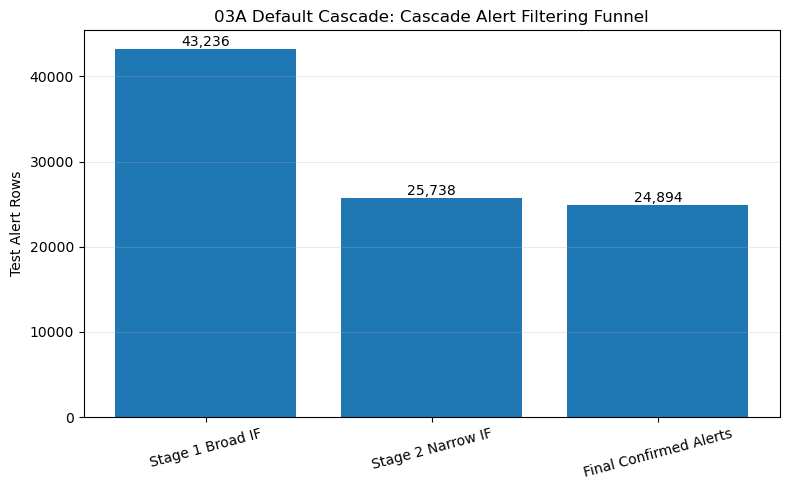

Saved cascade funnel chart: /workspace/artifacts/gold/pump/pump__gold__03a_default_cascade__cascade_funnel.png


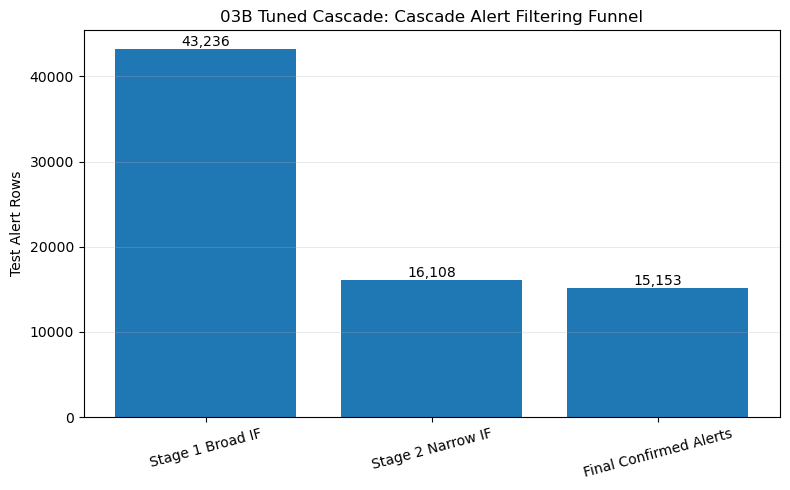

Saved cascade funnel chart: /workspace/artifacts/gold/pump/pump__gold__03b_tuned_cascade__cascade_funnel.png


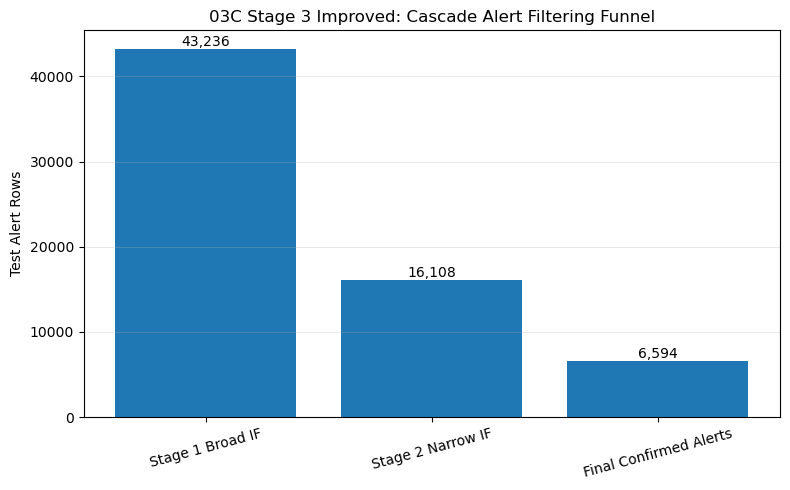

Saved cascade funnel chart: /workspace/artifacts/gold/pump/pump__gold__03c_stage_3_improved__cascade_funnel.png


In [ ]:
def build_cascade_funnel_dataframe(
    cascade_summary: dict,
    *,
    model_label: str,
) -> pd.DataFrame:
    """
    Build a stage-by-stage cascade funnel from saved cascade summary values.
    """
    return pd.DataFrame(
        [
            {
                "model": model_label,
                "stage": "Stage 1 Broad IF",
                "test_alerts": int(cascade_summary["stage1_alert_count_test_rows"]),
            },
            {
                "model": model_label,
                "stage": "Stage 2 Narrow IF",
                "test_alerts": int(cascade_summary["stage2_alert_count_test_rows"]),
            },
            {
                "model": model_label,
                "stage": "Final Confirmed Alerts",
                "test_alerts": int(cascade_summary["final_cascade_alert_count_test_rows"]),
            },
        ]
    )


In [ ]:
cascade_funnel_dataframe = pd.concat(
    [
        build_cascade_funnel_dataframe(
            cascade_defaults_summary,
            model_label="03A Default Cascade",
        ),
        build_cascade_funnel_dataframe(
            cascade_tuned_summary,
            model_label="03B Tuned Cascade",
        ),
        build_cascade_funnel_dataframe(
            cascade_stage3_improved_summary,
            model_label="03C Stage 3 Improved",
        ),
    ],
    ignore_index=True,
)

display(cascade_funnel_dataframe)

In [ ]:
for raw_model_name, model_frame in cascade_funnel_dataframe.groupby("model"):
    model_name = str(raw_model_name)

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        model_frame["stage"],
        model_frame["test_alerts"],
    )

    ax.set_title(f"{model_name}: Cascade Alert Filtering Funnel")
    ax.set_ylabel("Test Alert Rows")
    ax.grid(axis="y", linewidth=0.5, alpha=0.4)

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height()):,}",
            ha="center",
            va="bottom",
        )

    plt.xticks(rotation=15)
    plt.tight_layout()

    safe_model_name = (
        model_name
        .strip()
        .lower()
        .replace(" ", "_")
        .replace(":", "")
    )

    funnel_plot_path = (
        GOLD_COMPARISON_ARTIFACT_DIRS["plots"]
        / f"{DATASET_NAME}__gold__{safe_model_name}__cascade_funnel.png"
    )

    fig.savefig(funnel_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved cascade funnel chart: {funnel_plot_path}")

## Compare Stage 3 Operating Modes

### Ask

Why compare Stage 3 modes separately?

### Answer

The Stage 3 improved notebook may produce multiple operating modes or variants.

This comparison helps show how the final alert behavior changes when Stage 3 becomes stricter or more relaxed. It supports the project explanation by separating model-performance results from operational alert-volume tradeoffs.

,model,alert_count_test_rows,precision,recall,f1
4,Stage 3 Relaxed,13713,0.005834,0.677966,0.011568
5,Stage 3 Medium,7286,0.010705,0.661017,0.021070
3,Stage 3 Improved,6594,0.010616,0.593220,0.020858
6,Stage 3 Strict,61,0.442623,0.228814,0.301676


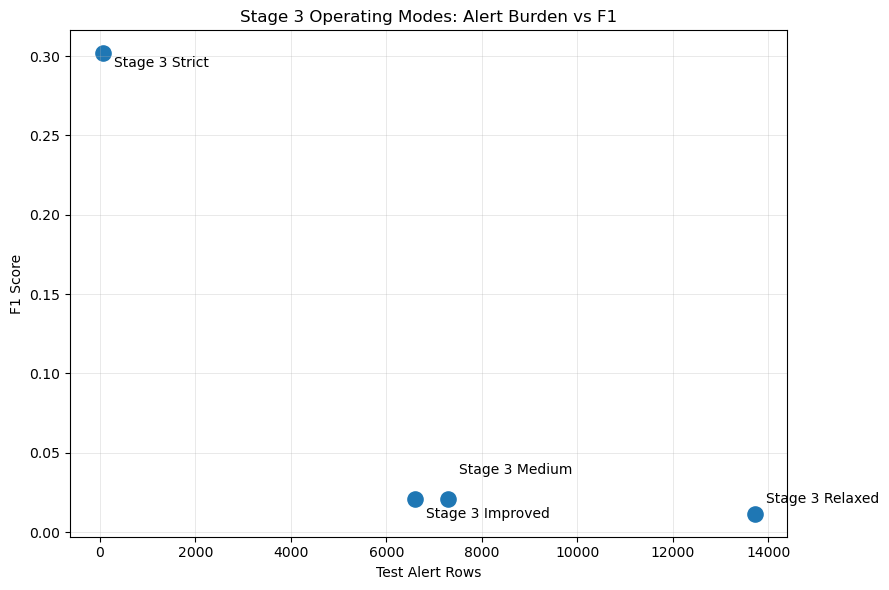

Saved Stage 3 operating-mode chart: /workspace/artifacts/gold/pump/pump__gold__stage3_operating_modes_alerts_vs_f1.png


In [ ]:
stage3_mode_dataframe = comparison_df.loc[
    comparison_df["model_id"].isin(
        [
            "stage3_improved",
            "stage3_relaxed",
            "stage3_medium",
            "stage3_strict",
        ]
    ),
    ["model", "alert_count_test_rows", "precision", "recall", "f1"],
].copy()

stage3_mode_dataframe = stage3_mode_dataframe.sort_values(
    by="alert_count_test_rows",
    ascending=False,
)

display(stage3_mode_dataframe)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    stage3_mode_dataframe["alert_count_test_rows"],
    stage3_mode_dataframe["f1"],
    s=120,
)

label_offsets = {
    "Stage 3 Relaxed": (8, 8),
    "Stage 3 Medium": (8, 18),
    "Stage 3 Improved": (8, -14),
    "Stage 3 Strict": (8, -10),
}

for _, row in stage3_mode_dataframe.iterrows():
    offset = label_offsets.get(row["model"], (6, 6))
    ax.annotate(
        row["model"],
        (row["alert_count_test_rows"], row["f1"]),
        textcoords="offset points",
        xytext=offset,
    )

ax.set_title("Stage 3 Operating Modes: Alert Burden vs F1")
ax.set_xlabel("Test Alert Rows")
ax.set_ylabel("F1 Score")
ax.grid(True, linewidth=0.5, alpha=0.4)

plt.tight_layout()

stage3_mode_plot_path = (
    GOLD_COMPARISON_ARTIFACT_DIRS["plots"]
    / f"{DATASET_NAME}__gold__stage3_operating_modes_alerts_vs_f1.png"
)


fig.savefig(stage3_mode_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved Stage 3 operating-mode chart: {stage3_mode_plot_path}")

## Build the Comparison Truth Record and Save the Comparison Artifacts

Now I convert the comparison results into a formal pipeline artifact.

This section does several important things:
- attaches Gold parent context to the comparison summary
- builds the Gold comparison truth record
- stamps lineage columns onto the comparison dataframe
- saves the comparison CSV
- saves the comparison summary JSON
- saves the comparison truth record
- logs the saved outputs in the ledger

At this point, the comparison output becomes more than just notebook output. It becomes a tracked deliverable in the pipeline.

In [ ]:
comparison_summary["gold_truth_hash"] = GOLD_PARENT_TRUTH_HASH
comparison_summary["gold_truth_path"] = str(GOLD_TRUTH_PATH)
comparison_summary["gold_process_run_id"] = gold_truth.get("process_run_id")
comparison_summary["gold_feature_set_id"] = gold_truth_runtime_facts.get("feature_set_id")

truth_config_object = globals().get("TRUTH_CONFIG")
run_mode_value = globals().get("RUN_MODE")
config_profile_value = globals().get("CONFIG_PROFILE", "default")
gold_process_run_id_value = globals().get("GOLD_PROCESS_RUN_ID")

if isinstance(truth_config_object, dict):
    truth_config_snapshot = truth_config_object
else:
    truth_config_snapshot = {
        "runtime": {
            "stage": "gold_comparison",
            "dataset": DATASET_NAME,
            "mode": run_mode_value,
            "profile": config_profile_value,
        }
    }

comparison_truth_layer_name = "gold_comparison"

if isinstance(gold_process_run_id_value, str) and gold_process_run_id_value.strip():
    comparison_process_run_id = gold_process_run_id_value
else:
    comparison_process_run_id = make_process_run_id("gold_comparison_process")

comparison_truth = initialize_layer_truth(
    truth_version=TRUTH_VERSION,
    dataset_name=DATASET_NAME,
    layer_name=comparison_truth_layer_name,
    process_run_id=comparison_process_run_id,
    pipeline_mode=PIPELINE_MODE,
    parent_truth_hash=GOLD_PARENT_TRUTH_HASH,
)

comparison_truth = update_truth_section(
    comparison_truth,
    "config_snapshot",
    truth_config_snapshot,
)

comparison_truth = update_truth_section(
    comparison_truth,
    "runtime_facts",
    {
        "comparison_row_count": int(len(comparison_df)),
        "baseline_result_row_count": int(len(baseline_results)),
        "cascade_default_result_row_count": int(len(cascade_defaults_results)),
        "cascade_tuned_result_row_count": int(len(cascade_tuned_results)),
        "cascade_stage3_improved_result_row_count": int(len(cascade_stage3_improved_results)),
        "shared_gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
        "baseline_truth_hash": BASELINE_TRUTH_HASH,
        "cascade_default_truth_hash": CASCADE_DEFAULTS_TRUTH_HASH,
        "cascade_tuned_truth_hash": CASCADE_TUNED_TRUTH_HASH,
        "cascade_stage3_improved_truth_hash": CASCADE_STAGE3_IMPROVED_TRUTH_HASH,
        "best_model_by_precision": comparison_summary["best_model_by_precision"],
        "best_model_by_recall": comparison_summary["best_model_by_recall"],
        "best_model_by_f1": comparison_summary["best_model_by_f1"],
        "best_model_by_alert_reduction": comparison_summary["best_model_by_alert_reduction"],
    },
)

comparison_truth = update_truth_section(
    comparison_truth,
    "artifact_paths",
    {
        "gold_truth_path": str(GOLD_TRUTH_PATH),

        "baseline_results_path_csv": str(BASELINE_RESULTS_PATH_CSV),
        "baseline_results_path_pickle": str(BASELINE_RESULTS_PATH_PICKLE),
        "baseline_summary_path": str(BASELINE_SUMMARY_PATH),
        "baseline_thresholds_path": str(BASELINE_THRESHOLDS_PATH),
        "baseline_metadata_path": str(BASELINE_METADATA_PATH),

        "cascade_default_results_path_csv": str(CASCADE_DEFAULTS_RESULTS_PATH_CSV),
        "cascade_default_results_path_pickle": str(CASCADE_DEFAULTS_RESULTS_PATH_PICKLE),
        "cascade_default_summary_path": str(CASCADE_DEFAULTS_SUMMARY_PATH),
        "cascade_default_thresholds_path": str(CASCADE_DEFAULTS_THRESHOLDS_PATH),
        "cascade_default_metadata_path": str(CASCADE_DEFAULTS_METADATA_PATH),

        "cascade_tuned_results_path_csv": str(CASCADE_TUNED_RESULTS_PATH_CSV),
        "cascade_tuned_results_path_pickle": str(CASCADE_TUNED_RESULTS_PATH_PICKLE),
        "cascade_tuned_summary_path": str(CASCADE_TUNED_SUMMARY_PATH),
        "cascade_tuned_thresholds_path": str(CASCADE_TUNED_THRESHOLDS_PATH),
        "cascade_tuned_metadata_path": str(CASCADE_TUNED_METADATA_PATH),

        "cascade_stage3_improved_results_path_csv": str(CASCADE_STAGE3_RESULTS_PATH_CSV),
        "cascade_stage3_improved_results_path_pickle": str(CASCADE_STAGE3_RESULTS_PATH_PICKLE),
        "cascade_stage3_improved_summary_path": str(CASCADE_STAGE3_SUMMARY_PATH),
        "cascade_stage3_improved_thresholds_path": str(CASCADE_STAGE3_THRESHOLDS_PATH),
        "cascade_stage3_improved_metadata_path": str(CASCADE_STAGE3_METADATA_PATH),

        "model_comparison_path": str(MODEL_COMPARISON_PATH),
        "model_comparison_summary_path": str(MODEL_COMPARISON_SUMMARY_PATH),
    },
)

comparison_meta_columns = sorted(
    set(
        identify_meta_columns(comparison_df)
        + [
            "meta__truth_hash",
            "meta__parent_truth_hash",
            "meta__pipeline_mode",
        ]
    )
)

comparison_feature_columns = identify_feature_columns(comparison_df)

comparison_truth_record = build_truth_record(
    truth_base=comparison_truth,
    row_count=len(comparison_df),
    column_count=comparison_df.shape[1] + 3,
    meta_columns=comparison_meta_columns,
    feature_columns=comparison_feature_columns,
)

COMPARISON_TRUTH_HASH = comparison_truth_record["truth_hash"]

comparison_df = stamp_truth_columns(
    comparison_df,
    truth_hash=COMPARISON_TRUTH_HASH,
    parent_truth_hash=GOLD_PARENT_TRUTH_HASH,
    pipeline_mode=PIPELINE_MODE,
)

comparison_truth_path = save_truth_record(
    comparison_truth_record,
    truth_dir=TRUTHS_PATH,
    dataset_name=DATASET_NAME,
    layer_name=comparison_truth_layer_name,
)

append_truth_index(
    comparison_truth_record,
    truth_index_path=TRUTH_INDEX_PATH,
)

comparison_summary["comparison_truth_hash"] = COMPARISON_TRUTH_HASH
comparison_summary["comparison_truth_path"] = str(comparison_truth_path)
comparison_summary["comparison_process_run_id"] = comparison_process_run_id

comparison_df.to_csv(MODEL_COMPARISON_PATH, index=False)
save_json(comparison_summary, MODEL_COMPARISON_SUMMARY_PATH)

wandb_run_object = globals().get("wandb_run")

if wandb_run_object is not None:
    wandb_run_object.save(str(MODEL_COMPARISON_PATH))
    wandb_run_object.save(str(MODEL_COMPARISON_SUMMARY_PATH))
    wandb_run_object.save(str(comparison_truth_path))

ledger.add(
    kind="step",
    step="save_comparison_outputs",
    message="Saved final baseline versus cascade comparison outputs and comparison stage truth record.",
    data={
        "comparison_csv": str(MODEL_COMPARISON_PATH),
        "comparison_summary_json": str(MODEL_COMPARISON_SUMMARY_PATH),
        "comparison_rows": int(len(comparison_df)),
        "gold_truth_hash": GOLD_PARENT_TRUTH_HASH,
        "gold_truth_path": str(GOLD_TRUTH_PATH),
        "comparison_truth_hash": COMPARISON_TRUTH_HASH,
        "comparison_truth_path": str(comparison_truth_path),
    },
    logger=logger,
)

2026-05-10 02:39:20,197 | INFO | capstone.file_io | Saved JSON: /workspace/artifacts/gold/pump/pump__gold__model_comparison_summary.json
wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
2026-05-10 02:39:20,309 | INFO | capstone.gold | LEDGER | {'ts_utc': '2026-05-10T02:39:20.309496+00:00', 'stage': 'gold', 'recipe': 'gold_modeling__v001_model_comparison', 'kind': 'step', 'step': 'save_comparison_outputs', 'message': 'Saved final baseline versus cascade comparison outputs and comparison stage truth record.', 'why': None, 'consequence': None, 'data': {'comparison_csv': '/workspace/artifacts/gold/pump/pump__gold__model_comparison.csv', 'comparison_summary_json': '/workspace/artifacts/gold/pump/pump__gold__model_comparison_summary.json', 'comparison_rows': 7, 'gold_truth_hash': '14e102b74fc10d423853d71e4fc2ce83d4e79997763addf4a8e38fe2b96835cc', 'gold_truth_path': '/work

{'ts_utc': '2026-05-10T02:39:20.309496+00:00',
 'stage': 'gold',
 'recipe': 'gold_modeling__v001_model_comparison',
 'kind': 'step',
 'step': 'save_comparison_outputs',
 'message': 'Saved final baseline versus cascade comparison outputs and comparison stage truth record.',
 'why': None,
 'consequence': None,
 'data': {'comparison_csv': '/workspace/artifacts/gold/pump/pump__gold__model_comparison.csv',
  'comparison_summary_json': '/workspace/artifacts/gold/pump/pump__gold__model_comparison_summary.json',
  'comparison_rows': 7,
  'gold_truth_hash': '14e102b74fc10d423853d71e4fc2ce83d4e79997763addf4a8e38fe2b96835cc',
  'gold_truth_path': '/workspace/artifacts/truths/gold/pump__gold__truth__14e102b74fc10d423853d71e4fc2ce83d4e79997763addf4a8e38fe2b96835cc.json',
  'comparison_truth_hash': '9bed8d56b8d172cdbe1324b146cace07ccc7e7ca41cd6a7e078e92be13a3f725',
  'comparison_truth_path': '/workspace/artifacts/truths/gold_comparison/pump__gold_comparison__truth__9bed8d56b8d172cdbe1324b146cace07cc

----

## Finalize the Ledger and Close the Tracking Run

This step writes the comparison ledger to disk and cleanly closes the experiment tracking run.

By the time I get here, the important comparison work and artifact creation are already complete. So this section is mainly about wrapping up the notebook in a structured way.

In [ ]:
ledger.add(
    kind="step",
    step="finalize_comparison",
    message="Gold comparison notebook complete.",
    data={
        #"comparison_csv": str(BASELINE_VS_CASCADE_PATH),
        #"comparison_summary_json": str(BASELINE_VS_CASCADE_SUMMARY_PATH),
        "comparison_csv": str(MODEL_COMPARISON_PATH),
        "comparison_summary_json": str(MODEL_COMPARISON_SUMMARY_PATH),
        "comparison_summary": comparison_summary,
    },
    logger=logger,
)

#comparison_ledger_path = GOLD_ARTIFACTS_PATH / GOLD_COMPARISON_LEDGER_FILE_NAME
ledger.write_json(comparison_ledger_path)

wandb.save(str(comparison_ledger_path))
wandb_run.finish()

2026-05-10 02:39:20,603 | INFO | capstone.gold | LEDGER | {'ts_utc': '2026-05-10T02:39:20.603819+00:00', 'stage': 'gold', 'recipe': 'gold_modeling__v001_model_comparison', 'kind': 'step', 'step': 'finalize_comparison', 'message': 'Gold comparison notebook complete.', 'why': None, 'consequence': None, 'data': {'comparison_csv': '/workspace/artifacts/gold/pump/pump__gold__model_comparison.csv', 'comparison_summary_json': '/workspace/artifacts/gold/pump/pump__gold__model_comparison_summary.json', 'comparison_summary': {'baseline_alert_count_test_rows': 31200, 'cascade_default_alert_count_test_rows': 24894, 'cascade_tuned_alert_count_test_rows': 15153, 'stage3_improved_alert_count_test_rows': 6594, 'stage3_relaxed_alert_count_test_rows': 13713, 'stage3_medium_alert_count_test_rows': 7286, 'stage3_strict_alert_count_test_rows': 61, 'baseline_vs_default_alert_reduction_count': 6306, 'baseline_vs_default_alert_reduction_ratio': 0.2021153846153846, 'baseline_vs_tuned_alert_reduction_count': 16

----

## Visualize the Cascade Filtering Funnel

This chart focuses only on the two cascade variants and shows how alert counts change as rows move through the cascade stages:
- Stage 1 broad screening
- Stage 2 narrow confirmation
- final cascade output

I like this chart because it shows the internal behavior of the cascade instead of only the final metrics. That makes it easier to explain where the alert reduction is actually happening.

2026-05-10 02:39:26,895 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__model_comparison_summary.json


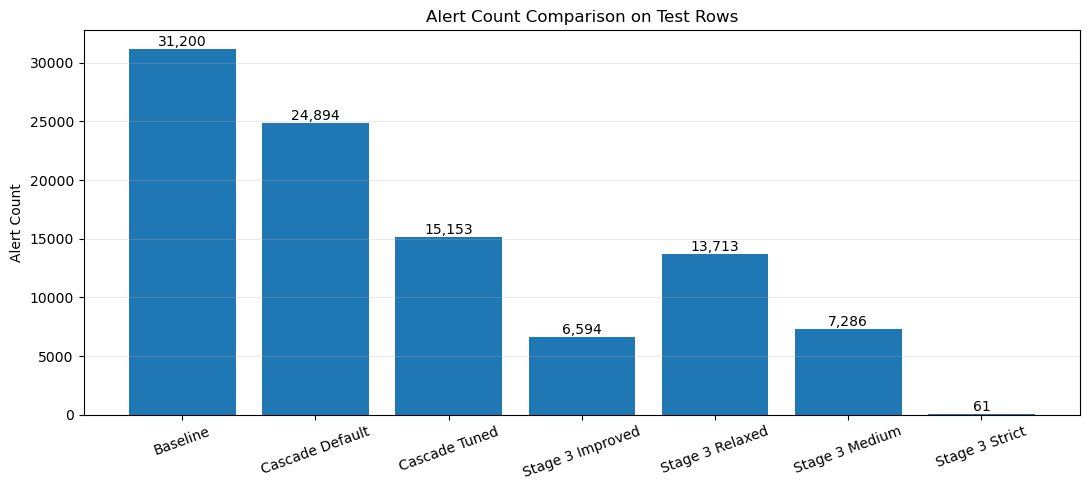

In [ ]:
# Funnel Filter Chart 

model_comparison_summary: dict[str, Any] = require_mapping(
    load_json(MODEL_COMPARISON_SUMMARY_PATH),
    "model_comparison_summary",
)

stages = [
    "Baseline",
    "Cascade Default",
    "Cascade Tuned",
    "Stage 3 Improved",
    "Stage 3 Relaxed",
    "Stage 3 Medium",
    "Stage 3 Strict",
]

counts = [
    int(model_comparison_summary["baseline_alert_count_test_rows"]),
    int(model_comparison_summary["cascade_default_alert_count_test_rows"]),
    int(model_comparison_summary["cascade_tuned_alert_count_test_rows"]),
    int(model_comparison_summary["stage3_improved_alert_count_test_rows"]),
    int(model_comparison_summary["stage3_relaxed_alert_count_test_rows"]),
    int(model_comparison_summary["stage3_medium_alert_count_test_rows"]),
    int(model_comparison_summary["stage3_strict_alert_count_test_rows"]),
]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(stages, counts)

ax.set_title("Alert Count Comparison on Test Rows")
ax.set_ylabel("Alert Count")
ax.grid(axis="y", linestyle="-", linewidth=0.5, alpha=0.4)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
    )

plt.xticks(rotation=20)
plt.tight_layout()

#comparison_alert_plot_path = GOLD_ARTIFACTS_PATH / f"{DATASET_NAME}__gold__alert_count_comparison_test_rows.png"
comparison_alert_plot_path = (
    GOLD_COMPARISON_ARTIFACT_DIRS["plots"]
    / f"{DATASET_NAME}__gold__alert_count_comparison_test_rows.png"
)
plt.savefig(comparison_alert_plot_path, dpi=200)
plt.show()


### Ask

What is this funnel chart helping me explain about the cascade?

### Answer

It helps me explain **where** the filtering pressure is happening.

If most of the alert drop happens between Stage 1 and Stage 2, then Stage 2 is acting as the main narrowing filter. If there is another large drop after that, then Stage 3 is doing most of the final cleanup. If the final stage barely changes the count, then Stage 3 may be too weak or mostly acting as a light confirmation layer.

So this chart helps me move from "the cascade changed the final count" to "this is the stage where the change actually happened."

----

## Run Final Lineage and Consistency Checks

Before I treat the comparison notebook as complete, I run a final sanity check on the saved comparison dataframe and truth artifacts.

This check verifies things like:
- required lineage columns exist in the comparison dataframe
- the dataframe truth hash matches the saved comparison truth
- the parent truth hash matches the shared Gold parent truth
- the saved truth file exists
- the saved comparison summary points back to the correct comparison truth hash
- the saved summary still references the correct baseline and cascade truth hashes

I like ending with this because it confirms that the comparison output is not only saved, but also internally consistent and traceable.

In [ ]:
required_comparison_meta_columns = [
    "meta__truth_hash",
    "meta__parent_truth_hash",
    "meta__pipeline_mode",
]

missing_comparison_meta_columns = [
    column_name
    for column_name in required_comparison_meta_columns
    if column_name not in comparison_df.columns
]
if missing_comparison_meta_columns:
    raise ValueError(
        f"comparison_df is missing required lineage columns: {missing_comparison_meta_columns}"
    )

comparison_df_truth_hash_check = extract_truth_hash(comparison_df)

if comparison_df_truth_hash_check is None:
    raise ValueError("comparison_df does not contain a readable meta__truth_hash value.")

if comparison_df_truth_hash_check != COMPARISON_TRUTH_HASH:
    raise ValueError(
        "comparison_df truth hash does not match COMPARISON_TRUTH_HASH:\n"
        f"dataframe={comparison_df_truth_hash_check}\n"
        f"record={COMPARISON_TRUTH_HASH}"
    )

comparison_parent_values = comparison_df["meta__parent_truth_hash"].dropna().astype(str).unique().tolist()

if not comparison_parent_values:
    raise ValueError("comparison_df is missing populated meta__parent_truth_hash values.")

if len(comparison_parent_values) != 1:
    raise ValueError(f"comparison_df has multiple parent truth hashes: {comparison_parent_values}")

if comparison_parent_values[0] != GOLD_PARENT_TRUTH_HASH:
    raise ValueError(
        "comparison_df parent truth hash does not match GOLD_PARENT_TRUTH_HASH:\n"
        f"dataframe_parent={comparison_parent_values[0]}\n"
        f"gold_parent={GOLD_PARENT_TRUTH_HASH}"
    )

if not Path(comparison_truth_path).exists():
    raise FileNotFoundError(f"Comparison truth file was not created: {comparison_truth_path}")

loaded_comparison_truth: dict[str, Any] = require_truth_record(
    load_json(comparison_truth_path),
    "loaded_comparison_truth",
)

if loaded_comparison_truth.get("truth_hash") != COMPARISON_TRUTH_HASH:
    raise ValueError(
        "Saved Comparison truth file hash does not match COMPARISON_TRUTH_HASH:\n"
        f"file={loaded_comparison_truth.get('truth_hash')}\n"
        f"record={COMPARISON_TRUTH_HASH}"
    )

if loaded_comparison_truth.get("parent_truth_hash") != GOLD_PARENT_TRUTH_HASH:
    raise ValueError(
        "Saved Comparison truth file parent hash does not match GOLD_PARENT_TRUTH_HASH:\n"
        f"truth={loaded_comparison_truth.get('parent_truth_hash')}\n"
        f"gold_parent={GOLD_PARENT_TRUTH_HASH}"
    )

saved_comparison_summary: dict[str, Any] = require_truth_record(
    load_json(MODEL_COMPARISON_SUMMARY_PATH),
    "saved_comparison_summary",
)

if saved_comparison_summary.get("baseline_truth_hash") != BASELINE_TRUTH_HASH:
    raise ValueError(
        "comparison_summary baseline_truth_hash does not match BASELINE_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('baseline_truth_hash')}\n"
        f"baseline={BASELINE_TRUTH_HASH}"
    )

if saved_comparison_summary.get("cascade_default_truth_hash") != CASCADE_DEFAULTS_TRUTH_HASH:
    raise ValueError(
        "comparison_summary cascade_default_truth_hash does not match CASCADE_DEFAULTS_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('cascade_default_truth_hash')}\n"
        f"default={CASCADE_DEFAULTS_TRUTH_HASH}"
    )

if saved_comparison_summary.get("cascade_tuned_truth_hash") != CASCADE_TUNED_TRUTH_HASH:
    raise ValueError(
        "comparison_summary cascade_tuned_truth_hash does not match CASCADE_TUNED_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('cascade_tuned_truth_hash')}\n"
        f"tuned={CASCADE_TUNED_TRUTH_HASH}"
    )

if saved_comparison_summary.get("cascade_stage3_improved_truth_hash") != CASCADE_STAGE3_IMPROVED_TRUTH_HASH:
    raise ValueError(
        "comparison_summary cascade_stage3_improved_truth_hash does not match CASCADE_STAGE3_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('cascade_stage3_improved_truth_hash')}\n"
        f"stage3={CASCADE_STAGE3_IMPROVED_TRUTH_HASH}"
    )

if saved_comparison_summary.get("gold_truth_hash") != GOLD_PARENT_TRUTH_HASH:
    raise ValueError(
        "comparison_summary gold_truth_hash does not match GOLD_PARENT_TRUTH_HASH:\n"
        f"summary={saved_comparison_summary.get('gold_truth_hash')}\n"
        f"gold={GOLD_PARENT_TRUTH_HASH}"
    )


print("Gold Comparison lineage sanity check passed.")

2026-05-10 02:39:27,331 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/truths/gold_comparison/pump__gold_comparison__truth__9bed8d56b8d172cdbe1324b146cace07ccc7e7ca41cd6a7e078e92be13a3f725.json


2026-05-10 02:39:27,345 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/gold/pump/pump__gold__model_comparison_summary.json


Gold Comparison lineage sanity check passed.


### Ask

What does this final sanity check really confirm?

### Answer

It confirms that the comparison results can be trusted as a pipeline artifact, not just as notebook output.

A comparison notebook can run successfully and still leave behind mismatched truth hashes, broken lineage, or saved summaries that no longer line up with the dataframe they are supposed to describe. This final check helps guard against that.

So this is really a trust check more than a completion check.

----


# Gold Comparison SQL Write Cell
Target:
- gold.model_comparison_results

Purpose:
- Persist the baseline-vs-cascade model comparison summary.


In [ ]:

WRITE_TO_POSTGRES = False

if WRITE_TO_POSTGRES:    
    
    gold_comparison_sql_summary_dataframe = write_gold_model_comparison_results_sql(
        engine=engine,
        capstone_schema=CAPSTONE_SCHEMA,
        dataset_id=DATASET_ID,
        run_id=RUN_ID,
        notebook_globals=globals(),
        dataset_name=globals().get("DATASET_NAME", DATASET_ID),
    )

    display(gold_comparison_sql_summary_dataframe)

else:
    print("Postgres write skipped.")

----